# <center> CAN in Databases, Speed, and Large Files
## <center> SYSE 549: Secure Vehicle and Industrial Networking
## <center><img src="https://www.engr.colostate.edu/~jdaily/Systems-EN-CSU-1-C357.svg" width="400" />
### <center> Instructor: Dr. Jeremy Daily

## Objective
Part 1 converted log files into the candump format and pulled two signals out of a seven-minute drive. This notebook asks what happens when CAN logging leaves the classroom: loggers run for days, files grow to gigabytes, and the same signals get pulled out again and again.

* Survey the open-source tools that already exist for J1939 work, and what each is good for.
* Measure whether a logger written in C or Rust is faster than one written in Python, using a PCAN adapter (or a simulator of one).
* Put a CAN log into an **SQLite database**, first by hand for two signals, then generally for every SPN in the **SAE J1939 Digital Annex**, which we also convert into a database.
* Measure how fast signals can be pulled out of the database compared with re-reading the text file.
* Stream a 2 GB cross-country log to extract its metadata, trip features and GPS track.

## How this notebook is organized
Every function used here is defined in this notebook, with comments, so there is nothing to install beyond the usual packages and nothing hidden in helper files. The pattern throughout is **hard-code an example first, then generalize**: we pull out engine speed by hand before we write a decoder that reads the Digital Annex, and we time one query before we build a benchmark. This is a learning notebook, not production code; where a shortcut makes the idea clearer, we take the shortcut and say so.

## Prerequisites
* Part 1, `CAN Log File Analysis.ipynb`, and the file `candump_kw_drive.txt` in this folder.
* Python packages: `pandas`, `matplotlib`, `openpyxl` (to read the Digital Annex). Optional: `python-can` for the Python logger, `folium` for the interactive map.
* The SAE J1939 Digital Annex spreadsheet, `J1939DA JUN2024.xlsx`, in this folder. It is licensed by SAE and is **not** in the git repository (see `.gitignore`); neither is the database we build from it.
* For the compiled loggers: a C compiler (`gcc`, or Visual Studio's `cl` from the *x64 Native Tools Command Prompt*) and, for Rust, `cargo` from https://rustup.rs. Their sources live in `pcan_logger/` because compiled languages need source files; the notebook builds and runs them.
* For the last section: `2014_KW_T270_cross_country_can_log.txt` (2 GB, download link in that section). Without it the section runs on the small drive log.

In [1]:
# Standard library only for the core work; pandas and matplotlib for tables and plots.
import os, sys, json, math, time, struct, sqlite3, subprocess, shutil, ctypes
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# A fixed set of colors used for every chart in this notebook (same order every time).
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
GRID = '#e1e0d9'

def tidy(ax):
    '''Light-weight chart styling: recessive grid, no top/right spines.'''
    ax.grid(color=GRID); ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| sqlite', sqlite3.sqlite_version)

Python 3.11.15 | pandas 3.0.2 | sqlite 3.45.1


# The Landscape: Open-Source J1939 Tools
Before writing our own tools it is worth knowing what already exists, because each project below solved a problem you will meet in this notebook. None of them is a substitute for understanding the protocol, which is the point of building things by hand here, but all of them are worth reading. The table is a snapshot from September 2026.

| Project | What it is | Good for | Notes |
|---|---|---|---|
| **pretty_j1939** (NMFTA) https://github.com/nmfta-repo/pretty_j1939 | Python library and command-line tool that turns candump lines into human-readable J1939 descriptions. Ships `create_j1939db-json`, which converts the SAE Digital Annex spreadsheet into a JSON database. | Decoding any log with names, units and enumerations; reassembling transport-protocol (BAM and RTS/CTS) messages; a reference implementation of the J1939 "not available / error / parameter specific" indicator rules. Its `da_parsers.py` is the hard-won knowledge of how to read every quirk of the Digital Annex's text columns. | MIT. The class file `J1939db.json` follows its JSON layout. The decoder in this notebook borrows its indicator thresholds (`0xFF` = not available, `0xFE` = error, `0xFB` = parameter specific). |
| **canarchy** (hexsecs) https://github.com/hexsecs/canarchy | A newer "stream-first CAN bus toolkit for analysts, security researchers, and AI agents": one CLI with JSON output for capture, decode, replay, compare and reverse engineering, with J1939 (PGN/SPN, TP, DM1, ECU inventory), UDS, DoIP and an MCP server. | Reverse engineering unknown IDs: per-byte entropy, counter and signal candidates with a written rationale, timing anomaly detection using median and MAD instead of mean and standard deviation, and comparing captures against a baseline (rate drop, rate spike, entropy collapse). | GPL-3.0. Works on Python lists rather than a database, so it is comfortable to about 10^5 frames per command; its interface ideas (bounded scans, "estimated" metadata from the head and tail of a huge file, parse-quality warnings) shaped the large-file section below. |
| **TruckDevil** (LittleBlondeDevil) https://github.com/LittleBlondeDevil/TruckDevil | "A framework for interacting with and assessing ECUs that use J1939 for communications on the CAN bus." Modules: `read_messages`, `send_messages`, `ecu_discovery`, `j1939_fuzzer`, plus user-written modules. | Security assessment of a live vehicle or bench ECU: discovering what is on the bus, sending crafted J1939 traffic, fuzzing PGNs. Integrates pretty_j1939 for display. | GPL-3.0, Python 3. Any python-can interface works (SocketCAN, PCAN); the Macchina M2 with the project's firmware is the recommended adapter. |
| **TruckHacking** (organization) https://github.com/TruckHacking | The projects around the **Truck Duck**, a BeagleBone-based heavy-vehicle diagnostic and debugging platform presented at DEF CON 24: `TruckDuckHardware` (schematics and Gerbers), `TruckKernel` (a BeagleBone kernel with J1939 sockets), `py-hv-networks` (Python interfaces to J1939 and J1708), `plc4trucksduck` (a PLC4TRUCKS / J2497 transmitter), `sr-j1708` (a sigrok decoder for J1708). | Getting at the *other* heavy-vehicle networks: J1708/J1587 and the power-line PLC4TRUCKS trailer link, and building your own low-cost interface hardware. The DEF CON paper is a readable introduction to why trucks are a distinct security problem. | Mixed licenses (GPL-3.0, MIT). Much of it is hardware-specific and less active than the software projects above, but the ideas are current. |
| **CAN Logger 3** (Systems Cyber, CSU) https://github.com/SystemsCyber/CAN-Logger-3 | "An open source secure data logging system for heavy vehicle networks": Teensy 3.6 hardware with three CAN channels and J1708, an SD card, and an ATECC608A secure element; firmware, a PyQt desktop app, and an AWS back end. | The problem this notebook keeps circling: capturing every frame and being able to *prove afterwards that the log is intact*. Logs are encrypted with a per-session key, the key is wrapped for the device and the server (envelope encryption), and the data is hashed and signed, so a log file is evidence rather than just a text file. | Compare with the candump text we use here, which anyone can edit with a text editor. `NMFTA CAN Logger 2 on a Navistar A26.bin` in this folder is a binary log from the previous generation. |
| **Linux can-j1939 + can-utils** https://github.com/linux-can/can-utils | The J1939 protocol lives in the mainline Linux kernel (`can-j1939` module): sockets that speak PGNs and addresses instead of raw frames, with transport protocol handled in the kernel. `can-utils` adds `j1939cat`, `j1939acd` (address claiming) and `j1939spy` next to `candump` and `canplayer`. | Writing J1939 applications on a Raspberry Pi without reimplementing TP or address claiming; replaying every log in this folder with `canplayer`. | GPL-2.0 / BSD. The `candump -l` format that all our logs use comes from here. |
| **python-can** https://github.com/hardbyte/python-can | The de facto Python CAN library: one API over SocketCAN, PCAN, Kvaser, Vector, IXXAT and others, with loggers and players for several file formats. | Portable capture scripts; the "Python" side of the logger comparison below. | LGPL-3.0. J1939 is not built in; combine with pretty_j1939 or the decoder written in this notebook. |

Two patterns stand out. Every decoding project eventually needs the **Digital Annex in a machine-readable form**, which is why we convert it to SQLite below. And every analysis project runs into the **size of real logs**, which is why the second half of this notebook is about databases and streaming.

# Helpers Used Throughout
Two functions from Part 1, restated here so this notebook stands alone: parse one candump line, and split a 29-bit identifier into its J1939 fields.

In [2]:
def parse_candump(line):
    '''Parse one candump -l line: '(1604007042.461135) can1 18FEBF0B#80067D7D79777B79'
    Returns (timestamp, channel, can_id, data_bytes). Raises ValueError on a malformed line.'''
    parts = line.split()
    timestamp = float(parts[0][1:-1])          # strip the parentheses
    channel = parts[1]
    id_text, _, data_text = parts[2].partition('#')
    can_id = int(id_text, 16)
    data = bytes.fromhex(data_text) if data_text and data_text[0] != 'R' else b''   # 'R' = remote frame
    return timestamp, channel, can_id, data

# J1939-21 identifier layout (29 bits): priority(3) | EDP(1) | DP(1) | PF(8) | PS(8) | SA(8)
def get_j1939_from_id(can_id):
    '''Return (priority, PGN, destination address, source address) for a 29-bit CAN ID.'''
    priority = (can_id >> 26) & 0x7
    PF = (can_id >> 16) & 0xFF          # PDU format
    PS = (can_id >> 8) & 0xFF           # PDU specific: destination (PDU1) or group extension (PDU2)
    SA = can_id & 0xFF
    if PF >= 0xF0:                       # PDU2: broadcast; the PS is part of the PGN
        PGN = (can_id >> 8) & 0x3FFFF
        DA = 0xFF
    else:                                # PDU1: peer to peer; the PS is the destination
        PGN = (can_id >> 8) & 0x3FF00
        DA = PS
    return priority, PGN, DA, SA

# Try them on one line from the drive log
t, ch, cid, data = parse_candump('(1604007042.467043) can1 0CF00400#718388001500F0FF')
print(t, ch, hex(cid), data.hex().upper(), get_j1939_from_id(cid))
assert get_j1939_from_id(0x0CF00400) == (3, 61444, 255, 0)     # EEC1 from Engine #1
assert get_j1939_from_id(0x18EA00F9) == (6, 59904, 0, 249)      # Request from diagnostic tool to engine

1604007042.467043 can1 0xcf00400 718388001500F0FF (3, 61444, 255, 0)


# Is a Compiled Logger Faster? C and Rust vs. Python on a PCAN Adapter
## The question
A J1939 network runs at 250 kbit/s. An extended-ID frame with 8 data bytes is about 130 bits on the wire including bit stuffing, so a fully loaded bus delivers roughly

$$\frac{250\,000\ \text{bit/s}}{130\ \text{bit/frame}} \approx 1\,900\ \text{frames/s}$$

and a 500 kbit/s bus about 3 800 frames/s. A logger has to receive, timestamp, format and write every one of those frames without falling behind. If it falls behind, the adapter's receive queue overflows and frames are silently lost, which is exactly what you cannot afford when the log is evidence.

The natural worry is that Python is too slow for this. Rather than guess, we measure. The same program exists in three languages, all talking to the PEAK-System **PCAN-Basic** API (`PCANBasic.dll` on Windows, `libpcanbasic.so` on Linux):

| Program | Where | How it talks to the adapter |
|---|---|---|
| C logger | `pcan_logger/pcan_logger.c` | Calls `CAN_Initialize`, `CAN_Read`, ... directly. Waits on the driver's receive event instead of polling. Formats hex by hand and writes through a 1 MiB buffer. |
| Rust logger | `pcan_logger/rust/src/main.rs` | The same functions declared in an `extern "system"` block (no crates), so the only difference from C is the language. |
| Python, ctypes | defined **below in this notebook** | The same functions through `ctypes`. Isolates the cost of the interpreter. |
| Python, python-can | defined **below in this notebook** | The `python-can` library, the way most people would write it. Adds the library's convenience layer on top. |

The C and Rust sources are files because compiled languages need files; the Python versions are cells here so you can read and change them. All four count frames, elapsed time, **CPU time** and, most importantly, the number of **receive-queue overruns** reported by the driver.

## Measuring without a truck
A benchmark needs identical input for every program, and a truck is not repeatable. `pcan_logger/pcan_sim/pcan_sim.c` is a *simulator* of the PCAN-Basic library: it exports the same functions, but instead of talking to hardware it replays a candump file. Compiled as `libpcanbasic.so` / `PCANBasic.dll` and placed first on the library search path, it lets all four loggers run on any computer and see exactly the same frames. It has two modes, selected with environment variables:

* **burst** (`PCAN_SIM_MODE=burst`): hand out frames as fast as the caller asks. This measures the *per-frame cost* of each implementation.
* **realtime** (`PCAN_SIM_MODE=realtime`, `PCAN_SIM_SPEED=10`): honour the timestamps in the file, sped up ten times. This checks whether each logger *keeps up* at about 3 300 frames/s and how much CPU it needs while idling between frames.

First the heart of the C program, the receive loop:

In [3]:
PCAN_DIR = os.path.abspath('pcan_logger')
SIM_DIR = os.path.join(PCAN_DIR, 'pcan_sim')
WINDOWS = sys.platform.startswith('win')

with open(os.path.join(PCAN_DIR, 'pcan_logger.c')) as f:
    c_source = f.read()
print(c_source[c_source.index('    while (!g_stop) {'):c_source.index('    double elapsed = wall_seconds()')])

    while (!g_stop) {
        if (run_secs > 0 && wall_seconds() - t_start >= run_secs) break;

        st = CAN_Read(ch, &msg, &ts);

        if (st == PCAN_ERROR_QRCVEMPTY) {
            /* Nothing queued: sleep until the driver signals, or briefly. */
#ifdef _WIN32
            if (have_event) WaitForSingleObject(ev, 50); else Sleep(1);
#else
            if (have_event) {
                fd_set rfds; FD_ZERO(&rfds); FD_SET(fd, &rfds);
                struct timeval tv = {0, 50000};
                select(fd + 1, &rfds, NULL, NULL, &tv);
            } else {
                usleep(200);
            }
#endif
            continue;
        }
        if (st & PCAN_ERROR_QOVERRUN) q_overruns++;   /* we were too slow: frames lost */
        if (st & PCAN_ERROR_OVERRUN)  ctrl_overruns++;
        if (st & ~(PCAN_ERROR_QOVERRUN | PCAN_ERROR_OVERRUN | PCAN_ERROR_ANYBUSERR)) {
            if (st != PCAN_ERROR_OK) die("CAN_Read", st);
        }
        if (msg.MSGTYPE & (PCAN_MESSAGE_STATUS | PCA

Three details in that loop matter more than the language:

* **Do not poll.** When `CAN_Read` reports an empty queue the program sleeps on the driver's receive event (a Windows event handle or a Linux file descriptor obtained with `PCAN_RECEIVE_EVENT`). A loop that spins on `CAN_Read` uses 100% of a core to do nothing.
* **Check the status bits.** `CAN_Read` returns `PCAN_ERROR_QOVERRUN` when the driver's queue overflowed. Counting those tells you whether frames were lost, which no amount of "it seemed fine" can.
* **Buffer the output.** One `write()` system call per frame costs more than formatting the frame. A 1 MiB buffer turns thousands of calls into a few.

## Building the simulator and the compiled loggers
The function below runs the compilers. It skips anything that is not installed and says so.

In [4]:
def run(cmd, cwd=PCAN_DIR, env=None):
    '''Run a command, echo it, raise on failure.'''
    print('  $', ' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=cwd, env=env)

def build_loggers():
    '''Compile pcan_sim (the simulator library), pcan_logger_sim (C, linked to it) and the Rust logger.
    Returns a dict telling which pieces exist afterwards.'''
    built = {'sim': False, 'c': False, 'rust': False}
    gcc, cl, cargo = shutil.which('gcc') or shutil.which('cc'), shutil.which('cl') if WINDOWS else None, shutil.which('cargo')
    sim_c = os.path.join('pcan_sim', 'pcan_sim.c')
    try:
        if WINDOWS and cl:      # MSVC: /LD makes a DLL; the import library PCANBasic.lib lands next to it
            run(['cl', '/nologo', '/O2', '/LD', sim_c, '/Fe:' + os.path.join('pcan_sim', 'PCANBasic.dll'), '/Fo:' + os.path.join('pcan_sim', 'pcan_sim.obj')])
            run(['cl', '/nologo', '/O2', 'pcan_logger.c', os.path.join('pcan_sim', 'PCANBasic.lib'), '/Fe:pcan_logger_sim.exe'])
        elif WINDOWS and gcc:   # MinGW
            run([gcc, '-O2', '-shared', '-o', os.path.join('pcan_sim', 'PCANBasic.dll'), sim_c])
            run([gcc, '-O2', '-o', 'pcan_logger_sim.exe', 'pcan_logger.c', '-Lpcan_sim', '-lPCANBasic'])
        elif gcc:               # Linux / macOS
            run([gcc, '-O2', '-shared', '-fPIC', '-Wl,-soname,libpcanbasic.so', '-o', os.path.join('pcan_sim', 'libpcanbasic.so'), sim_c, '-lpthread'])
            run([gcc, '-O2', '-o', 'pcan_logger_sim', 'pcan_logger.c', '-Lpcan_sim', '-lpcanbasic', '-Wl,-rpath,$ORIGIN/pcan_sim'])
        else:
            print('  no C compiler found (gcc or cl); cannot build the simulator or the C logger')
            return built
        built['sim'] = built['c'] = True
    except subprocess.CalledProcessError as e:
        print('  C build failed:', e)
        return built
    if cargo:
        try:
            run(['cargo', 'build', '--release', '--quiet'], cwd=os.path.join(PCAN_DIR, 'rust'), env=dict(os.environ, PCAN_LIB_DIR=SIM_DIR))
            built['rust'] = True
        except subprocess.CalledProcessError as e:
            print('  Rust build failed:', e)
    else:
        print('  cargo not found: skipping the Rust logger (install from https://rustup.rs)')
    return built

built = build_loggers()
built

  $ /usr/bin/gcc -O2 -shared -fPIC -Wl,-soname,libpcanbasic.so -o pcan_sim/libpcanbasic.so pcan_sim/pcan_sim.c -lpthread
  $ /usr/bin/gcc -O2 -o pcan_logger_sim pcan_logger.c -Lpcan_sim -lpcanbasic -Wl,-rpath,$ORIGIN/pcan_sim


  $ cargo build --release --quiet


{'sim': True, 'c': True, 'rust': True}

## The Python loggers
Here is the Python logger, twice. `python_ctypes_logger` declares the same four PCAN-Basic functions the C program uses and calls them through `ctypes`, so the only difference from C is the interpreter. `python_can_logger` uses `python-can`, which is how most people would write it. Both return the same statistics dictionary as the compiled programs.

Because these run *inside* the notebook's Python process, the simulator library is loaded into this kernel. That is fine for a benchmark; it means the environment variables that control the simulator must be set before the library is initialized, which the runner below takes care of.

In [5]:
# ---- PCAN-Basic constants (see pcan_logger/pcan_basic_min.h) ------------------------
PCAN_USBBUS1 = 0x51
PCAN_BAUD_250K = 0x011C
PCAN_ERROR_OK, PCAN_ERROR_OVERRUN, PCAN_ERROR_QRCVEMPTY, PCAN_ERROR_QOVERRUN, PCAN_ERROR_ANYBUSERR = 0x00, 0x02, 0x20, 0x40, 0x1C
PCAN_MESSAGE_RTR, PCAN_MESSAGE_EXTENDED, PCAN_MESSAGE_ERRFRAME, PCAN_MESSAGE_STATUS = 0x01, 0x02, 0x40, 0x80

class TPCANMsg(ctypes.Structure):
    _pack_ = 1
    _fields_ = [('ID', ctypes.c_uint32), ('MSGTYPE', ctypes.c_uint8), ('LEN', ctypes.c_uint8), ('DATA', ctypes.c_uint8 * 8)]

class TPCANTimestamp(ctypes.Structure):
    _pack_ = 1
    _fields_ = [('millis', ctypes.c_uint32), ('millis_overflow', ctypes.c_uint16), ('micros', ctypes.c_uint16)]

def load_pcan_library(directory=None):
    '''Load PCANBasic.dll / libpcanbasic.so, from `directory` if given, else from the system search path.'''
    name = 'PCANBasic.dll' if WINDOWS else 'libpcanbasic.so'
    lib = ctypes.CDLL(os.path.join(directory, name) if directory else name)
    lib.CAN_Initialize.argtypes = [ctypes.c_uint16, ctypes.c_uint16, ctypes.c_uint8, ctypes.c_uint32, ctypes.c_uint16]
    lib.CAN_Read.argtypes = [ctypes.c_uint16, ctypes.POINTER(TPCANMsg), ctypes.POINTER(TPCANTimestamp)]
    lib.CAN_Uninitialize.argtypes = [ctypes.c_uint16]
    for fn in (lib.CAN_Initialize, lib.CAN_Read, lib.CAN_Uninitialize):
        fn.restype = ctypes.c_uint32
    return lib

def format_candump(t, label, can_id, extended, data):
    '''One candump line, the same format Part 1 produced.'''
    return f"({t:.6f}) {label} {can_id:08X}#{data.hex().upper()}\n" if extended else f"({t:.6f}) {label} {can_id:03X}#{data.hex().upper()}\n"

def python_ctypes_logger(lib, out_path, seconds=0, quiet=False, label='can1', stop_when_empty=False):
    '''Log frames from channel PCAN_USBBUS1 to out_path until `seconds` pass (0 = no limit) or,
    with stop_when_empty, until the receive queue stays empty (the simulator has run out of frames).'''
    st = lib.CAN_Initialize(PCAN_USBBUS1, PCAN_BAUD_250K, 0, 0, 0)
    if st != PCAN_ERROR_OK:
        raise RuntimeError(f'CAN_Initialize failed: 0x{st:X}')
    msg, ts = TPCANMsg(), TPCANTimestamp()
    read = lib.CAN_Read                                  # local name: attribute lookups cost time in CPython
    frames = bytes_written = q_over = c_over = 0
    anchored, host_anchor, dev_anchor = False, 0.0, 0
    out = open(out_path, 'w', buffering=1 << 20)
    t_start, cpu_start = time.perf_counter(), time.process_time()
    while True:
        if seconds and time.perf_counter() - t_start >= seconds:
            break
        st = read(PCAN_USBBUS1, msg, ts)
        if st == PCAN_ERROR_QRCVEMPTY:
            if stop_when_empty:
                break
            time.sleep(0.0002)                           # simple polling; the C version waits on the driver's event
            continue
        if st & PCAN_ERROR_QOVERRUN: q_over += 1         # frames were lost because we read too slowly
        if st & PCAN_ERROR_OVERRUN:  c_over += 1
        if msg.MSGTYPE & (PCAN_MESSAGE_STATUS | PCAN_MESSAGE_ERRFRAME):
            continue
        dev_us = (ts.millis + (ts.millis_overflow << 32)) * 1000 + ts.micros   # device clock in microseconds
        if not anchored:                                 # anchor the device clock to the host clock once
            host_anchor, dev_anchor, anchored = time.time(), dev_us, True
        t = host_anchor + (dev_us - dev_anchor) / 1e6
        frames += 1
        if not quiet:
            line = format_candump(t, label, msg.ID, msg.MSGTYPE & PCAN_MESSAGE_EXTENDED, bytes(msg.DATA[:msg.LEN]))
            out.write(line); bytes_written += len(line)
    elapsed, cpu = time.perf_counter() - t_start, time.process_time() - cpu_start
    out.close(); lib.CAN_Uninitialize(PCAN_USBBUS1)
    return dict(language='Python (ctypes)', frames=frames, elapsed_s=elapsed, cpu_s=cpu,
                frames_per_s=frames / elapsed if elapsed else 0, cpu_us_per_frame=cpu * 1e6 / frames if frames else 0,
                rx_queue_overruns=q_over, ctrl_overruns=c_over, bytes_written=bytes_written)

def python_can_logger(out_path, seconds=0, quiet=False, label='can1', stop_when_empty=False, channel='PCAN_USBBUS1', bitrate=250000):
    '''The same logger written with python-can.'''
    import can                                           # pip install python-can
    bus = can.Bus(interface='pcan', channel=channel, bitrate=bitrate)
    out = open(out_path, 'w', buffering=1 << 20)
    frames = bytes_written = 0
    t_start, cpu_start = time.perf_counter(), time.process_time()
    while True:
        if seconds and time.perf_counter() - t_start >= seconds:
            break
        m = bus.recv(timeout=0.05)
        if m is None:
            if stop_when_empty:
                break
            continue
        if m.is_error_frame:
            continue
        frames += 1
        if not quiet:
            line = format_candump(m.timestamp, label, m.arbitration_id, m.is_extended_id, bytes(m.data))
            out.write(line); bytes_written += len(line)
    elapsed, cpu = time.perf_counter() - t_start, time.process_time() - cpu_start
    out.close(); bus.shutdown()
    return dict(language='Python (python-can)', frames=frames, elapsed_s=elapsed, cpu_s=cpu,
                frames_per_s=frames / elapsed if elapsed else 0, cpu_us_per_frame=cpu * 1e6 / frames if frames else 0,
                rx_queue_overruns=0, ctrl_overruns=0, bytes_written=bytes_written)

## Running the comparison
The runner sets the simulator's environment variables, runs the compiled programs as subprocesses (they print one JSON line of statistics on exit), runs the two Python loggers in this kernel, and collects everything into one table. Each logger is run three ways: burst mode writing the log, burst mode with output suppressed (the pure receive cost), and realtime at ten times the recorded rate for five seconds.

In [6]:
import tempfile

def sim_environment(candump_file, mode='burst', loops=5, speed=10, eof_sigint='0'):
    '''Environment variables that steer pcan_sim, plus the library search path so the simulator is found first.'''
    env = dict(os.environ, PCAN_SIM_FILE=os.path.abspath(candump_file), PCAN_SIM_MODE=mode,
               PCAN_SIM_LOOPS=str(loops), PCAN_SIM_SPEED=str(speed), PCAN_SIM_EOF_SIGINT=eof_sigint, PCAN_LIB_DIR=SIM_DIR)
    key = 'PATH' if WINDOWS else 'LD_LIBRARY_PATH'
    env[key] = SIM_DIR + os.pathsep + env.get(key, '')
    return env

def run_compiled(exe, env, out_path, seconds=0, quiet=False):
    '''Run a compiled logger and parse the JSON summary it prints to stderr.'''
    cmd = [exe, '-c', 'PCAN_USBBUS1', '-b', '250000', '-n', 'can1', '-o', out_path] + (['-t', str(seconds)] if seconds else []) + (['-q'] if quiet else [])
    p = subprocess.run(cmd, env=env, capture_output=True, text=True, cwd=PCAN_DIR)
    for line in reversed(p.stderr.strip().splitlines()):
        if line.startswith('{'):
            return json.loads(line)
    raise RuntimeError(f'{exe}: no summary line\n{p.stderr}')

def compare_loggers(candump_file='candump_kw_drive.txt', loops=5, speed=10, realtime_seconds=5):
    '''Run every available logger in three modes against the simulator. Returns a DataFrame.'''
    loggers = {}
    exe = os.path.join(PCAN_DIR, 'pcan_logger_sim' + ('.exe' if WINDOWS else ''))
    if os.path.exists(exe): loggers['C'] = exe
    exe = os.path.join(PCAN_DIR, 'rust', 'target', 'release', 'pcan_logger_rs' + ('.exe' if WINDOWS else ''))
    if os.path.exists(exe): loggers['Rust'] = exe
    try:
        import can; have_python_can = True
    except ImportError:
        have_python_can = False; print('python-can not installed: pip install python-can')

    tmp = tempfile.NamedTemporaryFile(prefix='pcan_bench_', suffix='.log', delete=False); tmp.close()
    out_path = tmp.name                                   # a real file, so writing to disk is part of the cost
    modes = [('burst', dict(mode='burst', loops=loops), dict(quiet=False, stop_when_empty=True)),
             ('burst-quiet', dict(mode='burst', loops=loops), dict(quiet=True, stop_when_empty=True)),
             (f'realtime x{speed}', dict(mode='realtime', loops=1000, speed=speed), dict(seconds=realtime_seconds))]
    rows = []
    for mode_name, sim_kw, run_kw in modes:
        env = sim_environment(candump_file, **sim_kw)
        # compiled programs: separate processes with the simulator's environment
        # (burst mode uses the simulator's end-of-file Ctrl-C to stop them)
        cenv = dict(env, PCAN_SIM_EOF_SIGINT='1' if mode_name.startswith('burst') else '0')
        for name, exe in loggers.items():
            r = run_compiled(exe, cenv, out_path, seconds=run_kw.get('seconds', 0), quiet=run_kw.get('quiet', False))
            rows.append(dict(r, logger=name, mode=mode_name))
        # Python loggers: in this process, so put the simulator's settings into our own environment first
        os.environ.update({k: env[k] for k in env if k.startswith('PCAN_') or k in ('PATH', 'LD_LIBRARY_PATH')})
        lib = load_pcan_library(SIM_DIR)
        r = python_ctypes_logger(lib, out_path, **run_kw); rows.append(dict(r, logger='Python (ctypes)', mode=mode_name))
        if have_python_can:
            r = python_can_logger(out_path, **run_kw); rows.append(dict(r, logger='Python (python-can)', mode=mode_name))
    os.remove(out_path)
    cols = ['logger', 'mode', 'frames', 'elapsed_s', 'cpu_s', 'frames_per_s', 'cpu_us_per_frame', 'rx_queue_overruns']
    return pd.DataFrame(rows)[cols].sort_values(['logger', 'mode'], key=lambda s: s.map({'C': 0, 'Rust': 1, 'Python (ctypes)': 2, 'Python (python-can)': 3}) if s.name == 'logger' else s).reset_index(drop=True)

if built['sim']:
    bench = compare_loggers()
    display(bench.round(3))
else:
    bench = None
    print('The simulator could not be built, so there is nothing to compare on this computer.')

uptime library not available, timestamps are relative to boot time and not to Epoch UTC


,logger,mode,frames,elapsed_s,cpu_s,frames_per_s,cpu_us_per_frame,rx_queue_overruns
0,C,burst,686545,0.144,0.143,4.770176e+06,0.210,0
1,C,burst-quiet,686545,0.006,0.006,1.202329e+08,0.010,0
2,C,realtime x10,16660,5.000,0.401,3.331700e+03,24.050,0
3,Rust,burst,686545,0.072,0.072,9.559784e+06,0.100,0
4,Rust,burst-quiet,686545,0.005,0.005,1.340972e+08,0.010,0
5,Rust,realtime x10,16660,5.000,0.393,3.331800e+03,23.610,0
6,Python (ctypes),burst,686545,1.035,1.035,6.630715e+05,1.508,0
7,Python (ctypes),burst-quiet,686545,0.405,0.405,1.696169e+06,0.590,0
8,Python (ctypes),realtime x10,16660,5.000,0.770,3.331810e+03,46.215,0
9,Python (python-can),burst,686545,3.023,3.027,2.271251e+05,4.409,0


,sustainable frames/s (one core),"250 kbit/s bus (~1,900 fr/s)","500 kbit/s bus (~3,800 fr/s)"
logger,,,
C,4761905.0,0.04% of a core,0.08% of a core
Rust,10000000.0,0.02% of a core,0.04% of a core
Python (ctypes),663247.0,0.29% of a core,0.57% of a core
Python (python-can),226813.0,0.84% of a core,1.68% of a core


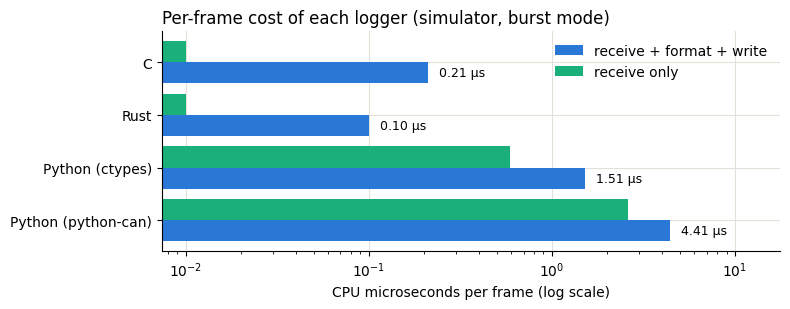

In [7]:
if bench is not None:
    burst = bench[bench['mode'] == 'burst'].set_index('logger')
    quiet = bench[bench['mode'] == 'burst-quiet'].set_index('logger')
    fig, ax = plt.subplots(figsize=(8, 3.2))
    y = range(len(burst))
    ax.barh([i + 0.2 for i in y], burst['cpu_us_per_frame'], height=0.4, color=BLUE, label='receive + format + write')
    ax.barh([i - 0.2 for i in y], quiet['cpu_us_per_frame'], height=0.4, color=AQUA, label='receive only')
    ax.set_yticks(list(y)); ax.set_yticklabels(burst.index); ax.invert_yaxis()
    ax.set_xscale('log'); ax.set_xlabel('CPU microseconds per frame (log scale)')
    ax.set_xlim(right=burst['cpu_us_per_frame'].max() * 4)
    ax.set_title('Per-frame cost of each logger (simulator, burst mode)', loc='left')
    for i, v in enumerate(burst['cpu_us_per_frame']):
        ax.text(v * 1.15, i + 0.2, f'{v:.2f} µs', va='center', fontsize=9)
    tidy(ax); ax.legend(frameon=False, loc='upper right'); plt.tight_layout()

    # Turn microseconds per frame into "how much of one core does a bus need?"
    capacity = pd.DataFrame({'sustainable frames/s (one core)': (1e6 / burst['cpu_us_per_frame']).round(0),
                             '250 kbit/s bus (~1,900 fr/s)': (1900 * burst['cpu_us_per_frame'] / 1e4).map('{:.2f}% of a core'.format),
                             '500 kbit/s bus (~3,800 fr/s)': (3800 * burst['cpu_us_per_frame'] / 1e4).map('{:.2f}% of a core'.format)})
    display(capacity)

## What the numbers say
On the machine that produced the stored output, the C and Rust loggers spend a fraction of a microsecond of CPU per frame, the raw `ctypes` Python loop about two microseconds, and `python-can` about five. So yes, **the compiled loggers are 10 to 20 times faster per frame**. The realtime rows, where every logger was fed the same 3 300 frames/s, show all four keeping up with zero queue overruns; the difference is how much of the processor each needs to do it.

Whether that matters depends on the job:

* A single 250 kbit/s J1939 bus needs about 1 900 frames/s. Even `python-can` handles that with a few percent of a laptop core, so a Python logger on a PC is fine. The compiled versions are not "faster" in any way a user would notice; the bottleneck is the bus, not the program.
* On a Raspberry Pi Zero or a microcontroller-class Linux board, on a 500 kbit/s or CAN FD network, or when logging **several channels at once**, the 10-20x per-frame cost starts to matter. Python also has the garbage collector and the global interpreter lock, which can stall the receive loop for milliseconds at a time; the queue overrun counter will show that as lost frames long before the average CPU load looks high.
* The C and Rust programs are identical in speed for practical purposes. Rust adds memory safety and a build system for the same performance, which is why it is a popular choice for new embedded logging tools.

The realtime CPU figures include the simulator's timing thread, which runs inside each logger's process, so use them to compare loggers with each other rather than as absolute costs. The Python loggers also ran inside this notebook's kernel rather than as separate processes; `time.process_time()` counts the kernel's other threads too, which is a small bias against Python.

### Running it on real hardware
Install the PCAN-Basic package from PEAK-System, build the C logger without the simulator (`make -f pcan_logger.mk` on Linux, `build.bat` on Windows with `PCANBasic.lib` and `PCANBasic.dll` copied into `pcan_logger/`), and run each logger for the same 30 seconds while traffic is on the bus:

```
pcan_logger/pcan_logger -c PCAN_USBBUS1 -b 250000 -t 30 -o c.log
pcan_logger/rust/target/release/pcan_logger_rs -c PCAN_USBBUS1 -b 250000 -t 30 -o rust.log
```

and in this notebook `python_ctypes_logger(load_pcan_library(), 'py.log', seconds=30)` and `python_can_logger('py2.log', seconds=30)`. The column to watch is `rx_queue_overruns`; a non-zero value means the logger lost frames.

### Exercise
1. Run the benchmark on the lowest-powered computer you have access to (a Raspberry Pi, or a laptop on battery-saver mode). Which loggers still show zero overruns in realtime mode at `speed=20`?
2. `python_ctypes_logger` polls with `time.sleep(0.0002)` when the queue is empty, while the C logger waits on the driver's receive event. Compare their CPU time in realtime mode. How would you wait on the event from Python? (Look up `PCAN_RECEIVE_EVENT` and `select`.)
3. The C logger formats hex by hand instead of calling `sprintf` for every byte. Replace `format_candump` in `pcan_logger.c` with a single `fprintf` and measure the difference in burst mode. Is text formatting or the system call the bigger cost?

# Putting a CAN Log into SQLite, by Hand First
## Why a database?
The candump text format is perfect for *logging*: append-only, human readable, understood by every tool. It is a poor format for *analysis*. To plot engine speed in Part 1 we scanned every line, split it, converted the ID from hex, and threw away 97% of the frames. Do that for ten signals and you scan the file ten times; do it on a 2 GB file and each scan takes minutes.

A database fixes this in two ways. The expensive parsing happens **once**, when the database is built; after that every column is a number. And an **index** lets the database jump straight to the rows that match a query, the way a book's index lets you skip to a page, instead of reading everything.

SQLite is the right database for this job: it is a single file, it is built into Python (`import sqlite3`), and it is fast enough that the whole cross-country log fits comfortably.

## The frames table
One row per frame. The columns are, in this order, the things you would want to search on, then the payload:

| column | type | meaning |
|---|---|---|
| `channel` | TEXT | `can0`, `can1`, ... |
| `sa` | INTEGER | J1939 source address |
| `pgn` | INTEGER | parameter group number |
| `da` | INTEGER | destination address (255 = global) |
| `can_id` | INTEGER | the full 29-bit identifier |
| `timestamp` | REAL | Unix seconds |
| `data` | BLOB | raw payload, 0 to 8 bytes |

An **index** over `(channel, sa, pgn, da, can_id, timestamp)` in that order means a query that fixes the channel, the source address and the PGN walks a small slice of a B-tree. The order matters: a composite index is like a phone book sorted by last name then first name, useless for finding everyone named "Jeremy". We will put that claim to the test later.

Let's build it for the seven-minute drive, with no cleverness at all.

In [8]:
LOG = 'candump_kw_drive.txt'
DB = 'candump_kw_drive.sqlite'

def create_frames_db(db_path):
    '''Create (or wipe and recreate) the database with the frames table.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    # Speed settings for a bulk load: no rollback journal, no fsync per transaction, a big page cache.
    # (We can always rebuild the database from the text file, so durability does not matter here.)
    conn.executescript('''
        PRAGMA journal_mode = OFF;
        PRAGMA synchronous = OFF;
        PRAGMA cache_size = -200000;
        CREATE TABLE frames (
            channel   TEXT    NOT NULL,
            sa        INTEGER NOT NULL,
            pgn       INTEGER NOT NULL,
            da        INTEGER NOT NULL,
            can_id    INTEGER NOT NULL,
            timestamp REAL    NOT NULL,
            data      BLOB
        );
    ''')
    return conn

def load_frames(conn, log_path, batch=50000):
    '''Stream a candump file into the frames table. Returns (frames inserted, bad lines).'''
    rows, n_bad, n = [], 0, 0
    id_cache = {}                                    # can_id -> (sa, pgn, da); there are only a few dozen unique IDs
    with open(log_path) as f:
        for line in f:
            try:
                timestamp, channel, can_id, data = parse_candump(line)
            except (ValueError, IndexError):
                n_bad += 1
                continue
            fields = id_cache.get(can_id)
            if fields is None:
                _, pgn, da, sa = get_j1939_from_id(can_id)
                fields = id_cache[can_id] = (sa, pgn, da)
            rows.append((channel, *fields, can_id, timestamp, data))
            if len(rows) >= batch:                   # executemany in batches is far faster than one execute per row
                conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?)', rows); rows.clear(); n += batch
    conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?)', rows); n += len(rows)
    conn.commit()
    return n, n_bad

t0 = time.perf_counter()
conn = create_frames_db(DB)
n_frames, n_bad = load_frames(conn, LOG)
t_load = time.perf_counter() - t0
t0 = time.perf_counter()
conn.execute('CREATE INDEX idx_frames_keys ON frames (channel, sa, pgn, da, can_id, timestamp)')
conn.commit()
t_index = time.perf_counter() - t0
print(f'{n_frames:,} frames loaded in {t_load:.2f} s ({n_frames/t_load:,.0f} frames/s), {n_bad} bad lines; index built in {t_index:.2f} s')
print(f'text {os.path.getsize(LOG)/1e6:.1f} MB -> database {os.path.getsize(DB)/1e6:.1f} MB')

137,309 frames loaded in 0.24 s (569,809 frames/s), 0 bad lines; index built in 0.11 s
text 7.1 MB -> database 10.9 MB


In [9]:
# pandas can run SQL straight against the connection, which is the easiest way to look at results
pd.read_sql_query("SELECT channel, sa, pgn, da, printf('%08X', can_id) AS id_hex, timestamp, hex(data) AS data FROM frames LIMIT 5", conn)

,channel,sa,pgn,da,id_hex,timestamp,data
0,can1,11,65215,255,18FEBF0B,1.604007e+09,80067D7D79777B79
1,can1,11,65134,255,08FE6E0B,1.604007e+09,8006800640062006
2,can1,0,61444,255,0CF00400,1.604007e+09,718388001500F0FF
3,can1,0,61444,255,0CF00400,1.604007e+09,218389001500F0FF
4,can1,11,65134,255,08FE6E0B,1.604007e+09,6006200640064006


In [10]:
# Who is talking, and how much? GROUP BY replaces the dictionary-counting loop from Part 1.
pd.read_sql_query('''
    SELECT sa, pgn, printf('%04X', pgn) AS pgn_hex, COUNT(*) AS frames
    FROM frames GROUP BY sa, pgn ORDER BY frames DESC LIMIT 12''', conn)

,sa,pgn,pgn_hex,frames
0,0,61444,F004,41156
1,11,65134,FE6E,20436
2,0,61443,F003,8231
3,49,61443,F003,8231
4,11,65215,FEBF,8175
5,0,65248,FEE0,4116
6,0,65265,FEF1,4116
7,0,65266,FEF2,4116
8,15,61440,F000,4116
9,49,61441,F001,4116


## Two signals, decoded by hand
Now the hard-coded part. From Part 1 we know exactly where two signals live:

* **SPN 190, Engine Speed**: PGN 61444 (EEC1), bytes 4-5, little-endian, 0.125 rpm per bit, no offset.
* **SPN 84, Wheel-Based Vehicle Speed**: PGN 65265 (CCVS1), bytes 2-3, little-endian, 1/256 km/h per bit, no offset.

We pull the matching frames out of `frames` with the index, decode them in Python with `struct.unpack`, and store the results in a second table, `signals(sa, spn, timestamp, value)`. Its index is `(sa, spn, timestamp)`: on a vehicle the source address barely varies (engine speed always comes from SA 0), so we lead with it and let the SPN split each address's rows into signals.

In [11]:
conn.executescript('''
    CREATE TABLE IF NOT EXISTS signals (
        sa        INTEGER NOT NULL,
        spn       INTEGER NOT NULL,
        timestamp REAL    NOT NULL,
        value     REAL
    );
    CREATE INDEX IF NOT EXISTS idx_signals ON signals (sa, spn, timestamp);
''')

def decode_hardcoded(conn, sa=0):
    '''Decode SPN 190 and SPN 84 from source address `sa` into the signals table, the Part 1 way.'''
    rows = []
    for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=? AND pgn=61444', (sa,)):
        rpm = struct.unpack('<H', data[3:5])[0] * 0.125          # bytes 4-5 -> Python indexes 3:5
        rows.append((sa, 190, timestamp, rpm))
    for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=? AND pgn=65265', (sa,)):
        kph = struct.unpack('<H', data[1:3])[0] / 256             # bytes 2-3 -> indexes 1:3
        rows.append((sa, 84, timestamp, kph))
    conn.execute('DELETE FROM signals WHERE sa=? AND spn IN (190, 84)', (sa,))
    conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', rows)
    conn.commit()
    return len(rows)

print(decode_hardcoded(conn), 'signal values stored')
pd.read_sql_query('SELECT spn, COUNT(*) AS n, MIN(value) AS min, MAX(value) AS max, AVG(value) AS mean FROM signals GROUP BY spn', conn)

45272 signal values stored


,spn,n,min,max,mean
0,84,4116,0.0,54.6875,22.36352
1,190,41156,568.5,1791.2500,994.61033


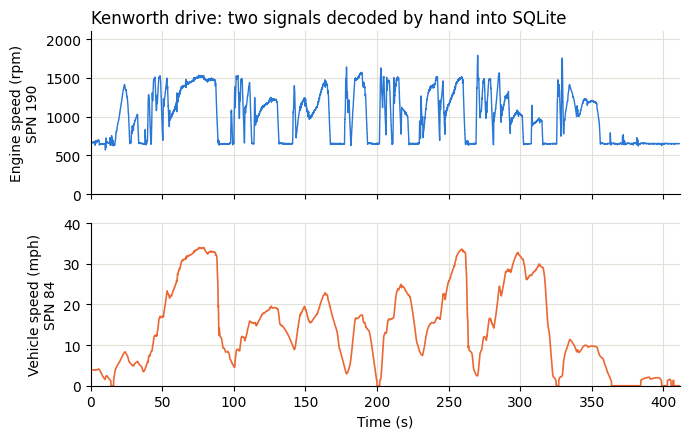

In [12]:
def plot_two_signals(conn, sa=0, title=''):
    '''Engine speed and vehicle speed from the signals table, stacked on a shared time axis.
    (Two units, two axes: a dual-axis chart would invite comparing heights that mean nothing.)'''
    rpm = pd.read_sql_query('SELECT timestamp, value FROM signals WHERE sa=? AND spn=190 ORDER BY timestamp', conn, params=(sa,))
    kph = pd.read_sql_query('SELECT timestamp, value FROM signals WHERE sa=? AND spn=84 ORDER BY timestamp', conn, params=(sa,))
    t0 = min(rpm['timestamp'].min(), kph['timestamp'].min())
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 4.5))
    ax1.plot(rpm['timestamp'] - t0, rpm['value'], color=BLUE, linewidth=1); ax1.set_ylabel('Engine speed (rpm)\nSPN 190'); ax1.set_ylim(0, 2100)
    ax2.plot(kph['timestamp'] - t0, kph['value'] * 0.621371, color=ORANGE, linewidth=1.2); ax2.set_ylabel('Vehicle speed (mph)\nSPN 84'); ax2.set_ylim(0, 40)
    ax2.set_xlabel('Time (s)'); ax1.set_title(title, loc='left'); ax1.autoscale(enable=True, axis='x', tight=True)
    tidy(ax1); tidy(ax2); plt.tight_layout()

plot_two_signals(conn, title='Kenworth drive: two signals decoded by hand into SQLite')

That is the whole idea, in about forty lines: parse once into `frames`, decode into `signals`, and from then on every plot is a `SELECT`. The trouble is the phrase *decoded by hand*. We knew the byte positions and scaling for two SPNs. The J1939 Digital Annex defines over thirty thousand. To generalize, we need the Digital Annex itself in a form a program can read.

# The J1939 Digital Annex as a Database
## What the Digital Annex is
SAE J1939 is published in two forms: the standard documents (J1939-71 and friends, prose and tables) and the **Digital Annex** (J1939DA), an Excel workbook that lists every parameter group and suspect parameter with its position, length, scaling, offset, range and description. Anyone decoding J1939 professionally works from the Digital Annex. It is licensed by SAE, which is why the spreadsheet and anything derived from it stay out of the public repository.

The workbook has a dozen sheets; the ones we need are

| Sheet | Contents |
|---|---|
| `SPs & PGs` | one row per (PGN, SPN) pair: ~32 000 rows, 44 columns |
| `Global Source Addresses (B2)` | the preferred source addresses 0-255 (Engine #1 = 0, Brakes = 11, ...) |
| `IG1 Source Addresses (B3)` | additional addresses for on-highway vehicles (industry group 1) |
| `Manufacturer IDs (B10)` | the manufacturer code used in the 64-bit J1939 NAME |
| `SLOTs` | the scaling / limit / offset / transfer-function definitions that SPNs refer to |

Older editions of the Digital Annex describe positions and scaling only as text ("4-5", "0.125 rpm/bit", "2 bytes"), and a converter has to parse every variant; pretty_j1939's `da_parsers.py` is 800 lines of exactly that. The 2024 edition adds machine-friendly columns (`SP Start Bit` as `byte.bit`, `Scale Factor (value only)`, `Offset (value only)`, `Length Minimum (bits)`), which we use here. If you have an older edition, look at how pretty_j1939 does it.

## Reading the spreadsheet
`pandas.read_excel` needs `openpyxl`. The header row of every sheet is row 4 (three title rows above it), so `header=3`. The workbook is 11 MB and takes about half a minute to read.

In [13]:
DA_XLSX = 'J1939DA JUN2024.xlsx'
DA_DB = 'J1939DA.sqlite'

t0 = time.perf_counter()
da = pd.read_excel(DA_XLSX, sheet_name=['SPs & PGs', 'Global Source Addresses (B2)', 'IG1 Source Addresses (B3)', 'Manufacturer IDs (B10)', 'SLOTs'], header=3)
print(f'read in {time.perf_counter()-t0:.1f} s:', {k: v.shape for k, v in da.items()})
spspg = da['SPs & PGs']
print(list(spspg.columns))

read in 6.6 s: {'SPs & PGs': (32763, 44), 'Global Source Addresses (B2)': (108, 5), 'IG1 Source Addresses (B3)': (74, 5), 'Manufacturer IDs (B10)': (1470, 5), 'SLOTs': (418, 16)}
['Revised', 'PG Revised', 'SP Revised', 'SP to PG Map Revised', 'PGN', 'PG Label', 'PG Acronym', 'PG Description', 'PDU Type', 'PGN Page', 'PG Data Length Class', 'PG Data Minimum Length', 'PG Data Length Constraint', 'PG Data Highest Assigned Byte', 'Transmission Rate', 'Default Priority', 'PG Reference', 'SP Position in PG', 'SP Start Bit', 'SPN', 'SP Label', 'SP Description', 'SP Length', 'Scaling', 'Offset', 'Data Range', 'Operational Range', 'Unit', 'SLOT Identifier', 'SLOT Name', 'SP Type', 'SP Reference', 'Scale Factor\n(value only)', 'Offset\n(value only)', 'Range Maximum\n(value only)', 'Length Minimum\n(bits)', 'Length Maximum\n(bits)', 'SP Document', 'PG Document', 'SP Created or Modified Date', 'PG Created or Modified Date', 'SP to PG Mapping Created or Modified Date', 'Row PG Content', 'Row SP Con

In [14]:
# One row, the way the Digital Annex sees engine speed
spspg[spspg['SPN'] == 190].iloc[0].dropna()

PGN                                                                                    61444.0
PG Label                                                        Electronic Engine Controller 1
PG Acronym                                                                                EEC1
PG Description                                                       Engine related parameters
PDU Type                                                                                  PDU2
PGN Page                                                                                Page 0
PG Data Length Class                                                                     Fixed
PG Data Minimum Length                                                                     8.0
PG Data Highest Assigned Byte                                                                8
Transmission Rate                            Fixed rate of 10 to 50 ms or engine speed depe...
Default Priority                                  

Note the units: the Digital Annex gives SPN 84 in **km/h at 1/256 km/h per bit**, while the class file `J1939db.json` had already converted it to mph (0.00242723 mph per bit is 1/256 km/h times 0.621371). Both are right; you have to know which one your decoder uses. Also note `SP Start Bit` is a number like `4.1` meaning *byte 4, bit 1* with bytes and bits numbered from 1, the J1939 convention; the LSB of byte 1 is bit position 0 in a little-endian 64-bit view of the payload.

## Schema
Three tables carry the SP/PG information. `pgns` and `spns` each hold one row per definition; `spn_pgn` records which SPN sits where in which PGN, because the same SPN can appear in more than one PGN (169 of them do in this edition), and the position is a property of the pair, not the SPN.

In [15]:
DA_SCHEMA = '''
CREATE TABLE pgns (
    pgn INTEGER PRIMARY KEY, label TEXT, acronym TEXT, description TEXT, pdu_type TEXT,
    length_class TEXT, min_length_bytes INTEGER, transmission_rate TEXT, default_priority INTEGER, document TEXT);
CREATE TABLE spns (
    spn INTEGER PRIMARY KEY, label TEXT, description TEXT, length_bits INTEGER, length_max_bits INTEGER,
    scale REAL, offset REAL, units TEXT, scaling_text TEXT, offset_text TEXT, data_range TEXT, operational_range TEXT,
    slot_id INTEGER, slot_name TEXT, sp_type TEXT, document TEXT);
CREATE TABLE spn_pgn (
    pgn INTEGER NOT NULL, spn INTEGER NOT NULL, position_text TEXT, start_bit INTEGER,
    PRIMARY KEY (pgn, spn));
CREATE INDEX idx_spn_pgn_spn ON spn_pgn (spn);
CREATE TABLE source_addresses (sa INTEGER PRIMARY KEY, name TEXT, notes TEXT, sheet TEXT);
CREATE TABLE manufacturers (id INTEGER PRIMARY KEY, name TEXT, location TEXT);
CREATE TABLE slots (slot_id INTEGER PRIMARY KEY, name TEXT, slot_type TEXT, scaling TEXT, range TEXT, offset TEXT, length TEXT, units TEXT);
'''

def start_bit_from_da(value):
    '''Digital Annex 'SP Start Bit' (e.g. 4.1 = byte 4, bit 1; both 1-based) -> 0-based bit offset in the payload.'''
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    byte = int(value)
    bit = int(round((float(value) - byte) * 10))
    return (byte - 1) * 8 + (bit - 1)

assert start_bit_from_da(1.1) == 0 and start_bit_from_da(4.1) == 24 and start_bit_from_da(2.5) == 12

def to_int(x):
    '''int or None for cells that may be blank, 'N/A', or text.'''
    try:
        return int(x)
    except (TypeError, ValueError):
        return None

def to_float(x):
    try:
        v = float(x); return None if math.isnan(v) else v
    except (TypeError, ValueError):
        return None

def text(x):
    return None if x is None or (isinstance(x, float) and math.isnan(x)) else str(x).strip()

In [16]:
def build_da_database(da, db_path=DA_DB):
    '''Load the Digital Annex DataFrames into an SQLite database.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    conn.executescript(DA_SCHEMA)
    sp = da['SPs & PGs']

    pgn_rows, spn_rows, map_rows = {}, {}, []
    for row in sp.to_dict('records'):                    # one dict per spreadsheet row, keyed by column name
        pgn, spn = to_int(row['PGN']), to_int(row['SPN'])
        if pgn is not None and pgn not in pgn_rows:
            pgn_rows[pgn] = (pgn, text(row['PG Label']), text(row['PG Acronym']), text(row['PG Description']), text(row['PDU Type']),
                             text(row['PG Data Length Class']), to_int(row['PG Data Minimum Length']), text(row['Transmission Rate']),
                             to_int(row['Default Priority']), text(row['PG Document']))
        if spn is not None and spn not in spn_rows:      # the first definition wins; the DA is consistent within an edition
            spn_rows[spn] = (spn, text(row['SP Label']), text(row['SP Description']), to_int(row['Length Minimum\n(bits)']),
                             to_int(row['Length Maximum\n(bits)']), to_float(row['Scale Factor\n(value only)']), to_float(row['Offset\n(value only)']),
                             text(row['Unit']), text(row['Scaling']), text(row['Offset']), text(row['Data Range']), text(row['Operational Range']),
                             to_int(row['SLOT Identifier']), text(row['SLOT Name']), text(row['SP Type']), text(row['SP Document']))
        if pgn is not None and spn is not None:
            map_rows.append((pgn, spn, text(row['SP Position in PG']), start_bit_from_da(to_float(row['SP Start Bit']))))

    conn.executemany('INSERT INTO pgns VALUES (?,?,?,?,?,?,?,?,?,?)', pgn_rows.values())
    conn.executemany('INSERT INTO spns VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)', spn_rows.values())
    conn.executemany('INSERT OR IGNORE INTO spn_pgn VALUES (?,?,?,?)', map_rows)

    # Source addresses: the global table, then industry group 1 (on-highway) for addresses the global table leaves open.
    for sheet in ('Global Source Addresses (B2)', 'IG1 Source Addresses (B3)'):
        for r in da[sheet].itertuples(index=False):
            sa = to_int(r[1])
            if sa is None:
                continue
            name, notes = text(r[2]), text(r[3])
            if name and name.lower().startswith('thru'):          # "thru 155 are reserved for ..." describes a range
                end = to_int(name.split()[1])
                for a in range(sa, (end or sa) + 1):
                    conn.execute('INSERT OR IGNORE INTO source_addresses VALUES (?,?,?,?)', (a, name.split(' are ', 1)[-1].capitalize(), notes, sheet))
            else:
                conn.execute('INSERT OR IGNORE INTO source_addresses VALUES (?,?,?,?)', (sa, name, notes, sheet))
    for r in da['Manufacturer IDs (B10)'].itertuples(index=False):
        if to_int(r[1]) is not None:
            conn.execute('INSERT OR IGNORE INTO manufacturers VALUES (?,?,?)', (to_int(r[1]), text(r[2]), text(r[3])))
    for r in da['SLOTs'].itertuples(index=False):
        if to_int(r[1]) is not None:
            conn.execute('INSERT OR IGNORE INTO slots VALUES (?,?,?,?,?,?,?,?)', (to_int(r[1]), text(r[2]), text(r[3]), text(r[4]), text(r[5]), text(r[6]), text(r[7]), text(r[8])))
    conn.commit()
    counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0] for t in ('pgns', 'spns', 'spn_pgn', 'source_addresses', 'manufacturers', 'slots')}
    return conn, counts

t0 = time.perf_counter()
dadb, counts = build_da_database(da)
print(f'built {DA_DB} in {time.perf_counter()-t0:.1f} s, {os.path.getsize(DA_DB)/1e6:.1f} MB:', counts)

built J1939DA.sqlite in 1.1 s, 14.8 MB: {'pgns': 3103, 'spns': 31469, 'spn_pgn': 15834, 'source_addresses': 256, 'manufacturers': 1470, 'slots': 418}


## Asking the Digital Annex questions
With the tables in place, the questions that used to mean scrolling through a spreadsheet become one-line queries.

In [17]:
# What is in EEC1, and where?
pd.read_sql_query('''
    SELECT m.spn, s.label, m.position_text AS position, m.start_bit, s.length_bits, s.scale, s.offset, s.units
    FROM spn_pgn m JOIN spns s ON s.spn = m.spn
    WHERE m.pgn = 61444 ORDER BY m.start_bit''', dadb)

,spn,label,position,start_bit,length_bits,scale,offset,units
0,899,Engine Torque Mode,1.1,0,4,1.000,0.0,NaN
1,4154,Actual Engine - Percent Torque (Fractional),1.5,4,4,0.125,0.0,%
2,512,Driver's Demand Engine - Percent Torque,2,8,8,1.000,-125.0,%
3,513,Actual Engine - Percent Torque,3,16,8,1.000,-125.0,%
4,190,Engine Speed,4-5,24,16,0.125,0.0,rpm
5,1483,Source Address of Controlling Device for Engin...,6,40,8,1.000,0.0,source address
6,1675,Engine Starter Mode,7.1,48,4,1.000,0.0,NaN
7,2432,Engine Demand – Percent Torque,8,56,8,1.000,-125.0,%


In [18]:
# Which PGNs carry engine speed? (an SPN can live in more than one parameter group)
print(pd.read_sql_query('SELECT m.pgn, p.acronym, p.label, m.position_text FROM spn_pgn m JOIN pgns p USING (pgn) WHERE m.spn = 190', dadb))
# Who is source address 11? 49? 0xF9?
print(pd.read_sql_query('SELECT sa, name FROM source_addresses WHERE sa IN (0, 11, 15, 49, 85, 249, 255)', dadb))

     pgn acronym                           label position_text
0  61444    EEC1  Electronic Engine Controller 1           4-5
    sa                                  name
0    0                             Engine #1
1   11            Brakes - System Controller
2   15                     Retarder - Engine
3   49              Cab Controller - Primary
4   85  Diesel Particulate Filter Controller
5  249  Off Board Diagnostic-Service Tool #1
6  255                 GLOBAL (All-Any Node)


In [19]:
# SQLite can open a second database file on the same connection, so one query can join the log against the Digital Annex.
conn.execute('ATTACH DATABASE ? AS da', (DA_DB,))

# Which PGNs in the drive log does the Digital Annex not know? Proprietary PGNs (PropA 61184, PropB 65280-65535)
# have a row in the Digital Annex but no SPNs, so we check for those separately.
unknown = pd.read_sql_query('''
    SELECT f.pgn, printf('%04X', f.pgn) AS hex, COUNT(*) AS frames FROM frames f
    WHERE f.pgn NOT IN (SELECT pgn FROM da.pgns) GROUP BY f.pgn ORDER BY frames DESC''', conn)
proprietary = pd.read_sql_query('''
    SELECT f.pgn, printf('%04X', f.pgn) AS hex, p.acronym, COUNT(*) AS frames FROM frames f JOIN da.pgns p USING (pgn)
    WHERE f.pgn = 61184 OR f.pgn BETWEEN 65280 AND 65535 GROUP BY f.pgn ORDER BY frames DESC''', conn)
n_pgns = conn.execute('SELECT COUNT(DISTINCT pgn) FROM frames').fetchone()[0]
print(f'{n_pgns} distinct PGNs in the log; {len(unknown)} not in the Digital Annex; {len(proprietary)} proprietary')
proprietary

41 distinct PGNs in the log; 0 not in the Digital Annex; 0 proprietary


,pgn,hex,acronym,frames


In [20]:
# The "who is talking" table from earlier, now with names from the Digital Annex
who = pd.read_sql_query('''
    SELECT f.sa, a.name AS source, f.pgn, printf('%04X', f.pgn) AS pgn_hex, p.acronym, p.label, COUNT(*) AS frames
    FROM frames f
    LEFT JOIN da.source_addresses a ON a.sa = f.sa
    LEFT JOIN da.pgns p ON p.pgn = f.pgn
    GROUP BY f.sa, f.pgn ORDER BY frames DESC''', conn)
who.head(15)

,sa,source,pgn,pgn_hex,acronym,label,frames
0,0,Engine #1,61444,F004,EEC1,Electronic Engine Controller 1,41156
1,11,Brakes - System Controller,65134,FE6E,HRW,High Resolution Wheel Speed,20436
2,0,Engine #1,61443,F003,EEC2,Electronic Engine Controller 2,8231
3,49,Cab Controller - Primary,61443,F003,EEC2,Electronic Engine Controller 2,8231
4,11,Brakes - System Controller,65215,FEBF,EBC2,Wheel Speed Information,8175
5,0,Engine #1,65248,FEE0,VD,Vehicle Distance,4116
6,0,Engine #1,65265,FEF1,CCVS1,Cruise Control/Vehicle Speed 1,4116
7,0,Engine #1,65266,FEF2,LFE1,Fuel Economy (Liquid),4116
8,15,Retarder - Engine,61440,F000,ERC1,Electronic Retarder Controller 1,4116
9,49,Cab Controller - Primary,61441,F001,EBC1,Electronic Brake Controller 1,4116


Every PGN in this drive log is defined in the 2024 Digital Annex, including `FE6E` High Resolution Wheel Speed and `FDA1` Aftertreatment 1 Fuel Control, which look exotic but are standard; the class file `J1939db.json` knew fewer than half of them. Logs from other trucks usually also contain **proprietary** PGNs (PropA 61184, PropB 65280-65535): the Digital Annex has a row for each of those but no SPNs, because the contents belong to the manufacturer. That is the general rule: the Digital Annex describes the standard, and each manufacturer keeps its own annex for the rest.

# Generalizing the Decoder
## From a table row to a value
Every decodable SPN in the Digital Annex is described by four numbers: `start_bit`, `length_bits`, `scale` and `offset`. Decoding is then the same three steps for every one of them:

1. View the payload as one little-endian integer (J1939 byte 1 is the least significant byte), shift right by `start_bit`, mask to `length_bits`. This is the raw value.
2. Check the **indicator bytes**. J1939-71 reserves the top of every field's range: for fields of a byte or more, a most-significant byte of `0xFF` means *not available*, `0xFE` means *error*, `0xFB` means *parameter specific*, `0xFC-0xFD` are reserved. For fields shorter than a byte, all ones means not available and all-ones-minus-one means error. (These thresholds are the ones pretty_j1939 uses; the class `J1939db.json` code in Part 1 skipped this step, which is why a 0xFFFF engine speed would have plotted as 8 191 rpm.)
3. `value = raw * scale + offset`.

Instead of a hand-written line per SPN, the plan for a PGN is now a list of `(spn, start_bit, length, scale, offset)` tuples pulled from the database.

In [21]:
def decode_plan(dadb, pgn):
    '''All decodable SPNs of a PGN as (spn, start_bit, length_bits, scale, offset), from the Digital Annex database.
    SPNs without a start bit or a fixed length (ASCII, variable-length, multi-packet-only) are left out.'''
    return dadb.execute('''
        SELECT m.spn, m.start_bit, s.length_bits, COALESCE(s.scale, 1.0), COALESCE(s.offset, 0.0)
        FROM spn_pgn m JOIN spns s ON s.spn = m.spn
        WHERE m.pgn = ? AND m.start_bit IS NOT NULL AND s.length_bits BETWEEN 1 AND 64
              AND s.length_bits = s.length_max_bits
        ORDER BY m.start_bit''', (pgn,)).fetchall()

def decode_spns(data, plan):
    '''Decode one payload with a plan. Returns {spn: engineering value}; indicator values (not available,
    error, parameter specific, reserved) decode to None so they never get plotted as data.'''
    raw64 = int.from_bytes(data.ljust(8, b'\xff'), 'little')     # missing bytes read as 0xFF = not available
    out = {}
    for spn, start, length, scale, offset in plan:
        raw = (raw64 >> start) & ((1 << length) - 1)
        if length >= 8:
            top = raw >> (length - 8)                              # most significant byte of the field
            if top >= 0xFB:                                        # FB parameter specific, FC-FD reserved, FE error, FF not available
                out[spn] = None
                continue
        elif length > 1 and raw >= (1 << length) - 2:              # short fields: all ones = N/A, one less = error
            out[spn] = None
            continue
        out[spn] = raw * scale + offset
    return out

eec1 = decode_plan(dadb, 61444)
print(eec1)
print(decode_spns(bytes.fromhex('718388001500F0FF'), eec1))     # the frame we decoded by hand earlier: 672 rpm

[(899, 0, 4, 1.0, 0.0), (4154, 4, 4, 0.125, 0.0), (512, 8, 8, 1.0, -125.0), (513, 16, 8, 1.0, -125.0), (190, 24, 16, 0.125, 0.0), (1483, 40, 8, 1.0, 0.0), (1675, 48, 4, 1.0, 0.0), (2432, 56, 8, 1.0, -125.0)]
{899: 1.0, 4154: 0.875, 512: 6.0, 513: 11.0, 190: 672.0, 1483: 0.0, 1675: 0.0, 2432: None}


In [22]:
# Check the generalized decoder against the hand-written one on every frame of the two PGNs
ccvs1 = decode_plan(dadb, 65265)
mismatch = 0
for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=0 AND pgn=61444'):
    if decode_spns(data, eec1)[190] != struct.unpack('<H', data[3:5])[0] * 0.125:
        mismatch += 1
for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=0 AND pgn=65265'):
    if abs(decode_spns(data, ccvs1)[84] - struct.unpack('<H', data[1:3])[0] / 256) > 1e-9:
        mismatch += 1
print('mismatches between the Digital Annex decoder and the hand-coded one:', mismatch)

mismatches between the Digital Annex decoder and the hand-coded one: 0


## The general database maker
Now `load_frames` can grow a decoded-values column. We add `spns TEXT` to the frames table, a JSON object of every SPN the plan could decode, and we fill the `signals` table for a chosen list of SPNs. The per-PGN plan is looked up once per unique CAN ID and cached, so the Digital Annex database is consulted a few dozen times, not once per frame.

The `spns` JSON column is the general answer ("every SPN, for any later question"); the `signals` table is the fast answer for the handful of SPNs you already know you will plot. Storing both costs disk, which is cheap, and saves the analyst's time, which is not.

In [23]:
def build_log_database(log_path, db_path, dadb, signal_spns=(190, 84), batch=50000, progress=True):
    '''candump text -> SQLite with J1939 keys, decoded SPNs (JSON) and a signals table for selected SPNs.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    conn.executescript('''
        PRAGMA journal_mode = OFF; PRAGMA synchronous = OFF; PRAGMA cache_size = -200000;
        CREATE TABLE frames (channel TEXT NOT NULL, sa INTEGER NOT NULL, pgn INTEGER NOT NULL, da INTEGER NOT NULL,
                             can_id INTEGER NOT NULL, timestamp REAL NOT NULL, data BLOB, spns TEXT);
        CREATE TABLE signals (sa INTEGER NOT NULL, spn INTEGER NOT NULL, timestamp REAL NOT NULL, value REAL);
        CREATE TABLE meta (key TEXT PRIMARY KEY, value TEXT);
    ''')
    signal_spns = set(signal_spns)
    id_cache = {}                                    # can_id -> (sa, pgn, da, plan)
    frame_rows, signal_rows = [], []
    n = n_bad = 0
    t0 = time.perf_counter()
    size = os.path.getsize(log_path)
    with open(log_path, errors='replace') as f:
        for line in f:
            try:
                timestamp, channel, can_id, data = parse_candump(line)
            except (ValueError, IndexError):
                n_bad += 1; continue
            info = id_cache.get(can_id)
            if info is None:
                _, pgn, da, sa = get_j1939_from_id(can_id)
                info = id_cache[can_id] = (sa, pgn, da, decode_plan(dadb, pgn))
            sa, pgn, da, plan = info
            spns_json = None
            if plan:
                values = decode_spns(data, plan)
                spns_json = json.dumps(values)
                for spn in signal_spns:
                    v = values.get(spn)
                    if v is not None:
                        signal_rows.append((sa, spn, timestamp, v))
            frame_rows.append((channel, sa, pgn, da, can_id, timestamp, data, spns_json))
            n += 1
            if len(frame_rows) >= batch:
                conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?,?)', frame_rows); frame_rows.clear()
                conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', signal_rows); signal_rows.clear()
                if progress:
                    print(f'\r  {n:>12,d} frames  {100*f.buffer.tell()/size:5.1f}%  {time.perf_counter()-t0:6.1f} s', end='')
    conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?,?)', frame_rows)
    conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', signal_rows)
    t_load = time.perf_counter() - t0
    t1 = time.perf_counter()
    conn.executescript('''
        CREATE INDEX idx_frames_keys ON frames (channel, sa, pgn, da, can_id, timestamp);
        CREATE INDEX idx_signals ON signals (sa, spn, timestamp);
    ''')
    t_index = time.perf_counter() - t1
    conn.executemany('INSERT INTO meta VALUES (?,?)', [('source_file', os.path.abspath(log_path)), ('frames', str(n)), ('bad_lines', str(n_bad)),
                                                        ('signal_spns', ','.join(map(str, sorted(signal_spns)))), ('load_s', f'{t_load:.1f}'), ('index_s', f'{t_index:.1f}')])
    conn.commit()
    if progress:
        print(f'\r  {n:,} frames in {t_load:.1f} s ({n/t_load:,.0f} frames/s), {n_bad} bad lines, indexes {t_index:.1f} s, {os.path.getsize(db_path)/1e6:.1f} MB')
    return conn

conn.close()
conn = build_log_database(LOG, DB, dadb, signal_spns=(190, 84, 91, 92, 245, 250, 247, 110, 171, 168))
conn.execute('ATTACH DATABASE ? AS da', (DA_DB,))
pd.read_sql_query("SELECT sa, pgn, printf('%08X', can_id) AS id_hex, timestamp, hex(data) AS data, spns FROM frames WHERE pgn IN (61444, 65262, 65253) GROUP BY pgn", conn)


        50,000 frames   36.5%     0.5 s


       100,000 frames   72.9%     1.0 s


  137,309 frames in 1.4 s (97,164 frames/s), 0 bad lines, indexes 0.3 s, 32.8 MB


,sa,pgn,id_hex,timestamp,data,spns
0,0,61444,0CF00400,1.604007e+09,718388001500F0FF,"{""899"": 1.0, ""4154"": 0.875, ""512"": 6.0, ""513"":..."
1,0,65253,18FEE500,1.604007e+09,1CFD0200BB630A00,"{""247"": 9793.4, ""249"": 680891000.0}"
2,0,65262,18FEEE00,1.604007e+09,724C1C2BFFFFFFFF,"{""110"": 74.0, ""174"": 36.0, ""175"": 71.875, ""176..."


In [24]:
# SQLite's JSON functions reach into the spns column, so any decoded SPN is one query away even if it is not in signals
pd.read_sql_query('''
    SELECT printf('%.1f', MIN(json_extract(spns, '$.110'))) AS coolant_min_C, printf('%.1f', MAX(json_extract(spns, '$.110'))) AS coolant_max_C,
           printf('%.1f', MAX(json_extract(spns, '$.245'))) AS odometer_km, printf('%.1f', MAX(json_extract(spns, '$.247'))) AS engine_hours
    FROM frames WHERE sa = 0 AND pgn IN (65262, 65248, 65253)''', conn)

,coolant_min_C,coolant_max_C,odometer_km,engine_hours
0,74.0,89.0,774890.6,9793.6


## How much did generalizing cost?
The hand-coded loader ran at well over 100 000 frames per second; the general one decodes every SPN of every known PGN and serializes it to JSON, and runs at a fraction of that. The database also grew, because the JSON is text. Both are still fast enough (the 2 GB cross-country log takes several minutes), and both happen once. If you only ever need a few SPNs, pass them in `signal_spns` and skip the JSON column; if you want everything available forever, keep it. That trade-off, *decode now or decode later*, is the real design decision in any log database.

### Exercise
1. Add SPN 91 (accelerator pedal position) and SPN 92 (engine percent load) to `plot_two_signals` as a third panel. They are already in the `signals` table.
2. The decoder treats `0xFE` (error) and `0xFF` (not available) the same way, as `None`. Change `decode_spns` to return the strings `'error'` and `'n/a'` instead, then count how many EEC1 frames in the drive log report an error in SPN 513 (actual engine percent torque).
3. Build the Digital Annex database from an older edition, if you have one. Which columns are missing, and how does pretty_j1939's `da_parsers.py` recover the start bit from the text position?

# Speed of Access: SQLite vs. the Flat Text File
## A meaningful measurement
Timing one query once tells you very little: the first run pays for reading the file into the operating system's cache, the second does not, and a fast machine finishes either before the clock ticks. Instead we run each method in a **timed loop for a fixed budget of seconds** and count how many complete extractions it finishes. The result is a rate (passes per second) that is stable, comparable, and answers "how many times could I re-plot this signal while the other method finishes once?"

The task is the one from the hard-coded section: pull **SPN 190 Engine Speed** and **SPN 84 Wheel-Based Vehicle Speed** from source address 0 as (time, value) series. Five methods do the same job:

1. **Text, parse everything.** The Part 1 approach: parse every line, decode the ID, keep the two PGNs.
2. **Text, string prefilter.** Check for the ID text (`0CF00400#`, `18FEF100#`) with `in` before parsing anything. A common and effective trick.
3. **SQLite frames, decode in Python.** Use the index to fetch only the matching rows' payloads, then unpack the bytes in Python.
4. **SQLite frames, JSON.** Use the index and let SQLite pull the value out of the `spns` JSON column.
5. **SQLite signals table.** The pre-extracted table: a pure index range scan.

All five must return identical values before we time them.

In [25]:
ENGINE = 0
ID_EEC1, ID_CCVS1 = 0x0CF00400, 0x18FEF100          # priority 3 / 6, PGN, SA 0

def method_text_parse_all(path=LOG):
    t190, v190, t84, v84 = [], [], [], []
    with open(path) as f:
        for line in f:
            timestamp, channel, can_id, data = parse_candump(line)
            _, pgn, da, sa = get_j1939_from_id(can_id)
            if sa != ENGINE:
                continue
            if pgn == 61444:
                t190.append(timestamp); v190.append(struct.unpack('<H', data[3:5])[0] * 0.125)
            elif pgn == 65265:
                t84.append(timestamp); v84.append(struct.unpack('<H', data[1:3])[0] / 256)
    return t190, v190, t84, v84

def method_text_prefilter(path=LOG):
    t190, v190, t84, v84 = [], [], [], []
    key190, key84 = f' {ID_EEC1:08X}#', f' {ID_CCVS1:08X}#'
    with open(path) as f:
        for line in f:
            if key190 in line:
                timestamp, channel, can_id, data = parse_candump(line)
                t190.append(timestamp); v190.append(struct.unpack('<H', data[3:5])[0] * 0.125)
            elif key84 in line:
                timestamp, channel, can_id, data = parse_candump(line)
                t84.append(timestamp); v84.append(struct.unpack('<H', data[1:3])[0] / 256)
    return t190, v190, t84, v84

def method_sqlite_blob(conn=conn):
    rows = conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=61444 ORDER BY timestamp", (ENGINE,)).fetchall()
    t190, v190 = [r[0] for r in rows], [struct.unpack('<H', r[1][3:5])[0] * 0.125 for r in rows]
    rows = conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=65265 ORDER BY timestamp", (ENGINE,)).fetchall()
    t84, v84 = [r[0] for r in rows], [struct.unpack('<H', r[1][1:3])[0] / 256 for r in rows]
    return t190, v190, t84, v84

def method_sqlite_json(conn=conn):
    rows = conn.execute("SELECT timestamp, json_extract(spns, '$.190') FROM frames WHERE channel='can1' AND sa=? AND pgn=61444 ORDER BY timestamp", (ENGINE,)).fetchall()
    t190, v190 = [r[0] for r in rows], [r[1] for r in rows]
    rows = conn.execute("SELECT timestamp, json_extract(spns, '$.84') FROM frames WHERE channel='can1' AND sa=? AND pgn=65265 ORDER BY timestamp", (ENGINE,)).fetchall()
    t84, v84 = [r[0] for r in rows], [r[1] for r in rows]
    return t190, v190, t84, v84

def method_sqlite_signals(conn=conn):
    rows = conn.execute('SELECT timestamp, value FROM signals WHERE sa=? AND spn=190 ORDER BY timestamp', (ENGINE,)).fetchall()
    t190, v190 = [r[0] for r in rows], [r[1] for r in rows]
    rows = conn.execute('SELECT timestamp, value FROM signals WHERE sa=? AND spn=84 ORDER BY timestamp', (ENGINE,)).fetchall()
    t84, v84 = [r[0] for r in rows], [r[1] for r in rows]
    return t190, v190, t84, v84

methods = {'1. text: parse every line': method_text_parse_all,
           '2. text: string prefilter': method_text_prefilter,
           '3. SQLite frames + unpack in Python': method_sqlite_blob,
           '4. SQLite frames + json_extract': method_sqlite_json,
           '5. SQLite signals table': method_sqlite_signals}

# Every method must give the same answer before we time anything.
import numpy as np
reference = method_text_parse_all()
for name, fn in methods.items():
    out = fn()
    same = all(np.allclose(a, b) for a, b in zip(reference, out))
    print(f'{name:38s} {len(out[0]):6d} engine-speed points, {len(out[2]):5d} vehicle-speed points, identical: {same}')

1. text: parse every line               41156 engine-speed points,  4116 vehicle-speed points, identical: True
2. text: string prefilter               41156 engine-speed points,  4116 vehicle-speed points, identical: True
3. SQLite frames + unpack in Python     41156 engine-speed points,  4116 vehicle-speed points, identical: True
4. SQLite frames + json_extract         41156 engine-speed points,  4116 vehicle-speed points, identical: True


5. SQLite signals table                 41156 engine-speed points,  4116 vehicle-speed points, identical: True


In [26]:
def timed_loop(fn, budget_s=3.0):
    '''Run fn() repeatedly for at least budget_s seconds. Returns (passes, seconds, seconds per pass).'''
    fn()                                                 # warm up: file cache, SQLite page cache
    passes, t0 = 0, time.perf_counter()
    while True:
        fn(); passes += 1
        elapsed = time.perf_counter() - t0
        if elapsed >= budget_s:
            return passes, elapsed, elapsed / passes

rows = []
for name, fn in methods.items():
    passes, elapsed, per = timed_loop(fn, budget_s=3.0)
    rows.append({'method': name, 'passes in 3 s': passes, 'ms per pass': per * 1e3, 'passes per second': passes / elapsed})
speed = pd.DataFrame(rows).set_index('method')
speed['speedup vs. method 1'] = speed['passes per second'] / speed['passes per second'].iloc[0]
speed.round(2)

,passes in 3 s,ms per pass,passes per second,speedup vs. method 1
method,,,,
1. text: parse every line,21,149.55,6.69,1.00
2. text: string prefilter,47,64.62,15.47,2.31
3. SQLite frames + unpack in Python,68,44.67,22.39,3.35
4. SQLite frames + json_extract,57,52.92,18.90,2.83
5. SQLite signals table,119,25.37,39.41,5.89


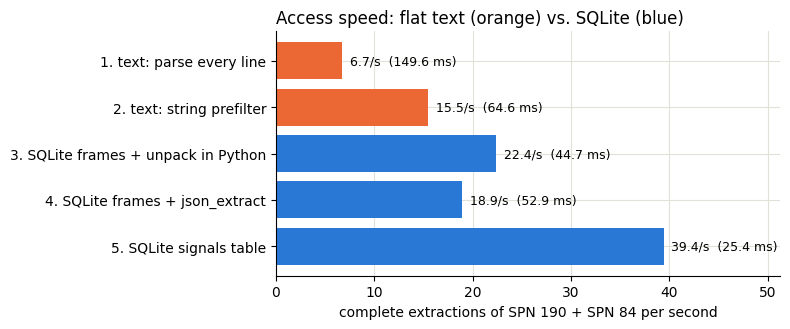

In [27]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(range(len(speed)), speed['passes per second'], color=[ORANGE, ORANGE, BLUE, BLUE, BLUE])
ax.set_yticks(range(len(speed))); ax.set_yticklabels(speed.index); ax.invert_yaxis()
ax.set_xlabel('complete extractions of SPN 190 + SPN 84 per second')
ax.set_title('Access speed: flat text (orange) vs. SQLite (blue)', loc='left')
ax.set_xlim(right=speed['passes per second'].max() * 1.3)
for i, (v, ms) in enumerate(zip(speed['passes per second'], speed['ms per pass'])):
    ax.text(v + speed['passes per second'].max() * 0.02, i, f'{v:,.1f}/s  ({ms:.1f} ms)', va='center', fontsize=9)
tidy(ax); plt.tight_layout()

Engine speed is a *bad* case for the database: a third of all frames in this log are EEC1, so even the indexed query hands back 41 000 rows and most of the time goes into building Python lists. The index shines when the answer is small. Engine hours (SPN 247, PGN 65253) is sent every ten seconds or so, 33 frames in this log, yet the text methods still have to read every line to find them.

In [28]:
ID_HOURS = 0x18FEE500

def hours_text_prefilter(path=LOG):
    key, out = f' {ID_HOURS:08X}#', []
    with open(path) as f:
        for line in f:
            if key in line:
                timestamp, channel, can_id, data = parse_candump(line)
                out.append((timestamp, struct.unpack('<I', data[0:4])[0] * 0.05))
    return out

def hours_sqlite(conn=conn):
    return [(t, struct.unpack('<I', d[0:4])[0] * 0.05) for t, d in
            conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=65253", (ENGINE,))]

assert hours_text_prefilter() == hours_sqlite()
rows = []
for name, fn in [('text: string prefilter', hours_text_prefilter), ('SQLite frames (indexed)', hours_sqlite)]:
    passes, elapsed, per = timed_loop(fn, budget_s=2.0)
    rows.append({'method': name, 'rows returned': len(fn()), 'ms per pass': per * 1e3, 'passes per second': passes / elapsed})
needle = pd.DataFrame(rows).set_index('method')
needle['speedup'] = needle['passes per second'] / needle['passes per second'].iloc[0]
needle.round(2)

,rows returned,ms per pass,passes per second,speedup
method,,,,
text: string prefilter,33,15.37,65.05,1.00
SQLite frames (indexed),33,0.04,26243.96,403.47


## Does the index order matter?
The `signals` index is `(sa, spn, timestamp)`. Would `(spn, sa, timestamp)` be faster? For a query that fixes both `sa` and `spn` the two are the same B-tree lookup, just with the key bytes in a different order, so we expect no difference. The order matters when a query fixes only the *leading* column: `WHERE sa = 0` can use `(sa, spn, ...)` but not `(spn, sa, ...)`, and `WHERE spn = 190` the other way round. Let's check rather than assert. `EXPLAIN QUERY PLAN` says which index SQLite chose; the timed loop says what it cost.

In [29]:
conn.execute('CREATE INDEX IF NOT EXISTS idx_signals_spn_first ON signals (spn, sa, timestamp)')
conn.commit()

queries = {
    'sa and spn fixed': 'SELECT timestamp, value FROM signals WHERE sa=0 AND spn=190',
    'only sa fixed':    'SELECT spn, timestamp, value FROM signals WHERE sa=0',
    'only spn fixed':   'SELECT sa, timestamp, value FROM signals WHERE spn=190',
}
for order, hint in [('(sa, spn, timestamp)', 'idx_signals'), ('(spn, sa, timestamp)', 'idx_signals_spn_first')]:
    print(f'--- index {order} ---')
    for label, q in queries.items():
        q_hinted = q.replace('FROM signals', f'FROM signals INDEXED BY {hint}')   # force the choice so we can time each
        try:
            plan = conn.execute('EXPLAIN QUERY PLAN ' + q_hinted).fetchall()[0][3]
            passes, elapsed, per = timed_loop(lambda: conn.execute(q_hinted).fetchall(), budget_s=1.0)
            print(f'{label:18s} {per*1e3:7.2f} ms/pass   {plan}')
        except sqlite3.OperationalError as e:
            print(f'{label:18s} cannot use this index: {e}')
conn.execute('DROP INDEX idx_signals_spn_first')
conn.commit()

--- index (sa, spn, timestamp) ---


sa and spn fixed     20.67 ms/pass   SEARCH signals USING INDEX idx_signals (sa=? AND spn=?)


only sa fixed        44.86 ms/pass   SEARCH signals USING INDEX idx_signals (sa=?)


only spn fixed       24.89 ms/pass   SCAN signals USING INDEX idx_signals
--- index (spn, sa, timestamp) ---


sa and spn fixed     19.70 ms/pass   SEARCH signals USING INDEX idx_signals_spn_first (spn=? AND sa=?)


only sa fixed        40.34 ms/pass   SCAN signals USING INDEX idx_signals_spn_first


only spn fixed       23.55 ms/pass   SEARCH signals USING INDEX idx_signals_spn_first (spn=?)


The measurement confirms the reasoning: with both columns fixed the two orders are indistinguishable, and each order can only `SEARCH` for the one-column query that starts with its leading column; the other becomes a `SCAN`. On this small table the scan is still quick, because the index *covers* the query (every column it needs is in the index) and there are only sixty thousand rows to walk; on the 2 GB log the gap between `SEARCH` and `SCAN` is the gap between milliseconds and minutes. So the choice comes down to which single-column question you are more likely to ask. "Everything from the engine" (`sa = 0`) is a common question on a vehicle network, where the source addresses are fixed and few, which is why `(sa, spn, timestamp)` is the order used here. If your queries were "SPN 190 from every ECU that reports it" across a fleet, you would lead with `spn`. A phone book sorted by last name is neither right nor wrong; it depends on what you look people up by.

## When does building the database pay for itself?

In [30]:
build_s = float(conn.execute("SELECT value FROM meta WHERE key='load_s'").fetchone()[0]) + float(conn.execute("SELECT value FROM meta WHERE key='index_s'").fetchone()[0])
per_text = speed.loc['1. text: parse every line', 'ms per pass'] / 1e3
per_db = speed.loc['3. SQLite frames + unpack in Python', 'ms per pass'] / 1e3
print(f'building the database took {build_s:.1f} s (including every SPN decoded to JSON)')
print(f'one text extraction takes {per_text*1e3:.0f} ms; one indexed SQLite extraction takes {per_db*1e3:.1f} ms')
print(f'break-even after about {build_s / (per_text - per_db):.0f} extractions -- every plot, every SPN, every re-run counts')

building the database took 1.7 s (including every SPN decoded to JSON)
one text extraction takes 150 ms; one indexed SQLite extraction takes 44.7 ms
break-even after about 16 extractions -- every plot, every SPN, every re-run counts


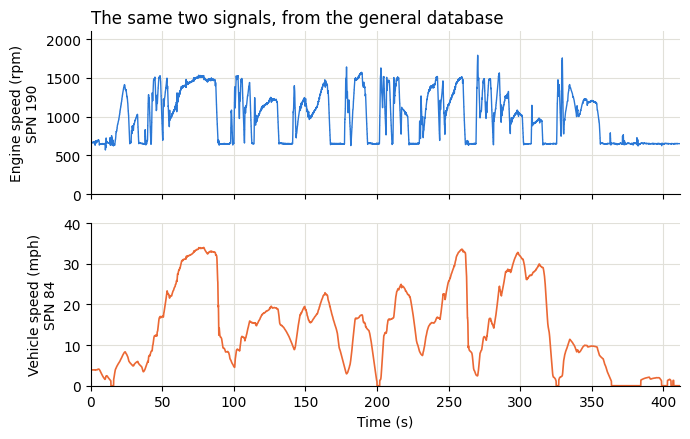

In [31]:
plot_two_signals(conn, title='The same two signals, from the general database')

## Discussion
The string prefilter (method 2) is worth remembering: skipping the parse for lines you do not want gives a real speedup for nothing, and it is how tools like `grep` stay fast. But it still reads the whole file, so its cost grows with the size of the *file*, while the indexed SQLite methods grow with the size of the *answer*. On this seven-minute log the answer for engine speed is 33% of the rows; for engine hours it is 0.02%, and there the index wins by two orders of magnitude.

The `signals` table is fastest because SQLite hands back exactly the two columns we want with no decoding at all. Its weakness is that you have to know which SPNs you want when you build it. The `spns` JSON column is the compromise: every decodable SPN is available without rebuilding, at the cost of parsing JSON per row.

Two more things a database gives you that a text file does not: several log files can be loaded into one database (add a `file` column) and queried together, and SQL aggregates (`GROUP BY sa, pgn`, `MAX(value)`, `AVG(value)`) answer questions about the whole log without writing a loop.

### Exercise
1. Method 4 asks SQLite to parse JSON for every row. Add a generated column, `ALTER TABLE frames ADD COLUMN spn190 REAL AS (json_extract(spns, '$.190'))`, index it, and time it. Is it as fast as the `signals` table?
2. Load `candump_kw_drive.txt` and `candump-2021-10-14_234124.log` into one database with a `file` column. Which source addresses appear in one vehicle and not the other?
3. Repeat the access-speed benchmark on the 2 GB log after building its database with `build_log_database`. How does the ratio between text and SQLite change, and why?

# Large File Analysis
## The data set
The file `2014_KW_T270_cross_country_can_log.txt` is a candump log from a 2014 Kenworth T270 on a cross-country trip, about **2 GB of text**. It can be downloaded from

https://systemscyber.engr.colostate.edu/cybersystems/data/HeavyVehicleCANData/2014_Kenworth_T270/2014_KW_T270_cross_country_can_log.zip

and unzipped into this folder (it is in `.gitignore`). A file of this size changes how you have to work:

* `f.readlines()` would need several gigabytes of RAM for the list of strings alone. Everything below **streams** the file one line at a time and keeps only counters and downsampled summaries in memory.
* One pass at a few hundred thousand lines per second takes a few minutes. That is fine once, not fine every time you re-run a cell. The analysis therefore makes **one pass** that collects everything we will need and caches the result beside the file (`*.features.json` and three small CSV files). Re-running the notebook reads the cache in milliseconds.
* Lifetime counters (odometer, total fuel, engine hours) are read from the first and last messages; per-second **means** are kept for the dynamic signals; GPS fixes are kept in full because there are only a few per minute.

canarchy has a useful habit for files like this: before any heavy pass, look at the first and last 64 kB and *estimate*. We start there.

In [32]:
BIG_FILE = '2014_KW_T270_cross_country_can_log.txt'
if not os.path.exists(BIG_FILE):
    print(f'{BIG_FILE} not found in {os.getcwd()}; falling back to candump_kw_drive.txt so the cells below still run.')
    BIG_FILE = LOG

def peek(path, chunk=65536):
    '''Get oriented in a huge candump file in milliseconds: read the head and the tail, estimate the rest.'''
    size = os.path.getsize(path)
    with open(path, 'rb') as f:
        head = f.read(chunk).decode(errors='replace').splitlines()
        f.seek(max(0, size - chunk))
        tail = f.read().decode(errors='replace').splitlines()
    good_head = [l for l in head[:-1] if l.startswith('(')]
    good_tail = [l for l in tail[1:] if l.startswith('(')]
    avg_line = sum(len(l) + 1 for l in good_head) / len(good_head)
    t_first, t_last = parse_candump(good_head[0])[0], parse_candump(good_tail[-1])[0]
    return {'size_GB': round(size / 1e9, 3), 'estimated_lines': int(size / avg_line), 'avg_line_bytes': round(avg_line, 1),
            'first_line': good_head[0], 'last_line': good_tail[-1],
            'start_utc': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(t_first)), 'end_utc': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(t_last)),
            'span_hours': round((t_last - t_first) / 3600, 2), 'scan_mode': 'estimated from head and tail'}

peek(BIG_FILE)

2014_KW_T270_cross_country_can_log.txt not found in /home/claude/work/nb2; falling back to candump_kw_drive.txt so the cells below still run.


{'size_GB': 0.007,
 'estimated_lines': 140015,
 'avg_line_bytes': 51.0,
 'first_line': '(1604007042.461135) can1 18FEBF0B#80067D7D79777B79',
 'last_line': '(1604007454.005724) can1 0CF00400#407D84521400F0FF',
 'start_utc': '2020-10-29 21:30:42',
 'end_utc': '2020-10-29 21:37:34',
 'span_hours': 0.11,
 'scan_mode': 'estimated from head and tail'}

## What one pass collects
| Feature | How |
|---|---|
| size, lines, frames, unparsable lines, first/last timestamp, duration | counters |
| per-channel, per-ID, per-source-address, per-PGN counts, DLC histogram | `collections.Counter` |
| frames per second (bus load) and gaps longer than a threshold (logging segments) | a counter keyed by `int(timestamp)` |
| per-second means of engine speed, vehicle speed, pedal, load, odometer, fuel, temperatures, voltage | decode only the PGNs that carry them, with plans from the Digital Annex database |
| GPS track from Vehicle Position (PGN 65267, SPNs 584/585) | decode, sanity-check, keep |
| the vehicle's own clock (Time/Date, PGN 65254) compared with the logger's timestamps | decode |
| VIN, Component ID and Software ID (multi-frame BAM messages) | a minimal J1939-21 transport-protocol reassembler |

The BAM reassembler is the one piece not seen in this notebook so far; multi-frame messages are covered fully in *05_J1939/04_Parse_J1939_Multi_Frame_Messages*. In short: a TP.CM frame (PGN 60416) with control byte 32 announces "here come N packets totalling M bytes of PGN X", then N TP.DT frames (PGN 60160) each carry a sequence number and seven bytes.

In [33]:
TP_CM, TP_DT = 60416, 60160                     # J1939-21 transport protocol: connection management, data transfer
ASCII_PGNS = {65260: 'VIN', 65259: 'Component ID', 65242: 'Software ID', 64965: 'ECU ID'}

class BAMReassembler:
    '''Minimal J1939-21 Broadcast Announce Message reassembly. Feed it every TP.CM and TP.DT frame;
    completed messages appear in .messages as (timestamp, sa, pgn, bytes).'''
    def __init__(self):
        self.sessions = {}        # sa -> [target pgn, total bytes, packet count, buffer, packets received]
        self.messages = []

    def feed(self, t, pgn, sa, data):
        if pgn == TP_CM and len(data) >= 8 and data[0] == 32:                 # 32 = BAM control byte
            total = data[1] | (data[2] << 8)
            packets = data[3]
            target_pgn = data[5] | (data[6] << 8) | (data[7] << 16)
            self.sessions[sa] = [target_pgn, total, packets, bytearray(), 0]
        elif pgn == TP_DT and sa in self.sessions and len(data) >= 2:
            s = self.sessions[sa]
            s[3].extend(data[1:8])                                             # byte 0 is the sequence number
            s[4] += 1
            if s[4] >= s[2]:
                self.messages.append((t, sa, s[0], bytes(s[3][:s[1]])))
                del self.sessions[sa]

# Quick self-test with the VIN broadcast pattern: one CM frame, then three DT frames carrying 'ABC...'
bam = BAMReassembler()
bam.feed(0.0, TP_CM, 0, bytes([32, 17, 0, 3, 0xFF, 0xEC, 0xFE, 0x00]))       # 17 bytes of PGN 0x00FEEC (65260) in 3 packets
bam.feed(0.1, TP_DT, 0, bytes([1]) + b'1XKAAP8')
bam.feed(0.2, TP_DT, 0, bytes([2]) + b'X4CJ293')
bam.feed(0.3, TP_DT, 0, bytes([3]) + b'142*\xff\xff\xff')
bam.messages

[(0.3, 0, 65260, b'1XKAAP8X4CJ293142')]

In [34]:
def haversine_km(lat1, lon1, lat2, lon2):
    '''Great-circle distance between two points, in km.'''
    R = 6371.0088
    p1, p2 = math.radians(lat1), math.radians(lat2)
    a = math.sin((p2 - p1) / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(math.radians(lon2 - lon1) / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

SIGNAL_SPNS = (190, 84, 91, 92, 245, 250, 247, 110, 175, 171, 108, 168, 183, 96)   # kept as per-second means
GPS_PGN, TIMEDATE_PGN = 65267, 65254

def analyze_big_log(path, dadb, signals=SIGNAL_SPNS, gap_seconds=60.0, progress_every=2_000_000, use_cache=True):
    '''One streaming pass over a candump file. Returns a dict of features and writes them beside the file.'''
    base = os.path.splitext(path)[0]
    out_json = base + '.features.json'
    if use_cache and os.path.exists(out_json) and os.path.getmtime(out_json) > os.path.getmtime(path):
        print('loaded cached results from', out_json)
        return json.load(open(out_json))

    signals = set(signals)
    # Which PGNs carry a signal we keep? Ask the Digital Annex once, then cache plans per PGN.
    wanted = {r[0] for spn in signals for r in dadb.execute('SELECT pgn FROM spn_pgn WHERE spn=?', (spn,))} | {GPS_PGN, TIMEDATE_PGN}
    plans = {pgn: decode_plan(dadb, pgn) for pgn in wanted}
    sa_names = dict(dadb.execute('SELECT sa, name FROM source_addresses'))
    pgn_names = {pgn: (acr, lab) for pgn, acr, lab in dadb.execute('SELECT pgn, acronym, label FROM pgns')}

    id_cache = {}
    chan_count, id_count, sa_count, pgn_count, sa_pgn_count, dlc_count = Counter(), Counter(), Counter(), Counter(), Counter(), Counter()
    per_second = Counter()                                       # int(t) -> frames: the bus-load timeline
    sig_sum, sig_n = defaultdict(Counter), defaultdict(Counter)  # spn -> {second: sum}, spn -> {second: count}
    gps, timedate, gaps = [], [], []
    n_timedate, timedate_sample = 0, None
    bam = BAMReassembler()
    n_lines = n_frames = n_bad = 0
    t_first = t_last = t_prev = None
    size, t0 = os.path.getsize(path), time.perf_counter()

    with open(path, errors='replace') as f:
        for line in f:
            n_lines += 1
            parts = line.split()
            try:
                t = float(parts[0][1:-1]); channel = parts[1]
                id_text, _, data_text = parts[2].partition('#')
                info = id_cache.get(id_text)
                if info is None:
                    can_id = int(id_text, 16)
                    _, pgn, da, sa = get_j1939_from_id(can_id)
                    info = id_cache[id_text] = (sa, pgn, plans.get(pgn), pgn in (TP_CM, TP_DT))
            except (IndexError, ValueError):
                n_bad += 1; continue
            sa, pgn, plan, is_tp = info
            n_frames += 1
            chan_count[channel] += 1; id_count[id_text] += 1; sa_count[sa] += 1; pgn_count[pgn] += 1
            sa_pgn_count[(sa, pgn)] += 1; dlc_count[len(data_text) // 2] += 1
            sec = int(t); per_second[sec] += 1
            if t_first is None: t_first = t
            if t_prev is not None and t - t_prev > gap_seconds: gaps.append((t - t_prev, t_prev, t))
            t_prev = t_last = t

            if plan or is_tp:                                    # decode only what we asked for
                data = bytes.fromhex(data_text)
                if is_tp:
                    bam.feed(t, pgn, sa, data); continue
                vals = decode_spns(data, plan)
                if pgn == GPS_PGN:
                    lat, lon = vals.get(584), vals.get(585)
                    if lat is not None and lon is not None and -90 <= lat <= 90 and -180 <= lon <= 180:
                        gps.append((t, lat, lon))
                elif pgn == TIMEDATE_PGN:
                    n_timedate += 1
                    s_, m_, h_, mo, d_, y_ = (vals.get(k) for k in (959, 960, 961, 963, 962, 964))
                    if timedate_sample is None: timedate_sample = dict(seconds=s_, minutes=m_, hours=h_, month=mo, day=d_, year=y_)
                    if None not in (s_, m_, h_, mo, d_, y_) and 1 <= mo <= 12 and 1 <= d_ <= 31.75:
                        import calendar
                        try: timedate.append((t, calendar.timegm((int(y_), int(mo), int(d_), int(h_), int(m_), int(s_), 0, 0, 0))))
                        except (ValueError, OverflowError): pass
                else:
                    for spn, v in vals.items():
                        if v is not None and spn in signals:
                            sig_sum[spn][sec] += v; sig_n[spn][sec] += 1
            if n_lines % progress_every == 0:
                print(f'\r  {n_lines:>12,d} lines  {100*f.buffer.tell()/size:5.1f}%  {time.perf_counter()-t0:6.0f} s', end='')
    elapsed = time.perf_counter() - t0
    print(f'\r  {n_lines:,} lines in {elapsed:.0f} s ({n_lines/elapsed:,.0f} lines/s)')

    # --- summaries ------------------------------------------------------------------------
    starts, ends = [t_first] + [g[2] for g in gaps], [g[1] for g in gaps] + [t_last]
    segments = [{'segment': i + 1, 'start': s, 'end': e, 'duration_s': e - s} for i, (s, e) in enumerate(zip(starts, ends))]
    gps_summary = None
    if gps:
        dist = sum(d for d in (haversine_km(a[1], a[2], b[1], b[2]) for a, b in zip(gps, gps[1:])) if d < 5.0)  # skip jumps between segments
        gps_summary = {'fixes': len(gps), 'start': gps[0][1:], 'end': gps[-1][1:], 'path_km': round(dist, 1),
                       'lat_min': min(g[1] for g in gps), 'lat_max': max(g[1] for g in gps), 'lon_min': min(g[2] for g in gps), 'lon_max': max(g[2] for g in gps)}
        pd.DataFrame(gps, columns=['timestamp', 'lat', 'lon']).to_csv(base + '.gps.csv', index=False)
    secs = sorted({s for spn in sig_sum for s in sig_sum[spn]})
    sig = pd.DataFrame({'second': secs})
    for spn in sorted(sig_sum):
        sig[f'spn{spn}'] = [sig_sum[spn][s] / sig_n[spn][s] if sig_n[spn][s] else None for s in secs]
    sig.to_csv(base + '.signals.csv', index=False)
    pd.DataFrame(sorted(per_second.items()), columns=['second', 'frames']).to_csv(base + '.busload.csv', index=False)
    ascii_msgs = {}
    for t, sa, pgn, payload in bam.messages:
        if pgn in ASCII_PGNS:
            ascii_msgs.setdefault(f'{ASCII_PGNS[pgn]} (PGN {pgn}) from SA {sa}', payload.split(b'*')[0].decode('ascii', 'replace').strip())
    clock = None
    if n_timedate:
        clock = {'messages': n_timedate, 'valid': len(timedate), 'sample': timedate_sample}
        if timedate:
            offsets = sorted(v - t for t, v in timedate)
            clock.update(median_offset_s=offsets[len(offsets) // 2],
                         vehicle_time_first=time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(timedate[0][1])),
                         vehicle_time_last=time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(timedate[-1][1])))
    rates = sorted(per_second.values())
    feats = {'file': os.path.abspath(path), 'size_bytes': size, 'lines': n_lines, 'frames': n_frames, 'bad_lines': n_bad, 'parse_seconds': round(elapsed, 1),
             't_first': t_first, 't_last': t_last, 'duration_s': t_last - t_first,
             'start_utc': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(t_first)), 'end_utc': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(t_last)),
             'frames_per_s_mean': round(n_frames / (t_last - t_first), 1), 'frames_per_s_median': rates[len(rates) // 2], 'frames_per_s_max': rates[-1],
             'seconds_with_traffic': len(per_second), 'channels': dict(chan_count), 'unique_ids': len(id_count),
             'dlc_histogram': {str(k): v for k, v in sorted(dlc_count.items())}, 'top_ids': id_count.most_common(25),
             'source_addresses': [{'sa': sa, 'name': sa_names.get(sa, 'Unknown'), 'frames': n} for sa, n in sa_count.most_common()],
             'pgns': [{'pgn': pgn, 'hex': f'{pgn:04X}', 'acronym': pgn_names.get(pgn, ('', ''))[0], 'label': pgn_names.get(pgn, ('', ''))[1], 'frames': n} for pgn, n in pgn_count.most_common()],
             'gaps': [{'gap_s': g, 'before': a, 'after': b} for g, a, b in sorted(gaps, reverse=True)[:50]], 'segments': segments,
             'gps': gps_summary, 'gps_csv': base + '.gps.csv' if gps else None, 'signals_csv': base + '.signals.csv', 'bus_load_csv': base + '.busload.csv',
             'signal_first_last': {str(spn): (sig[f'spn{spn}'].dropna().iloc[0], sig[f'spn{spn}'].dropna().iloc[-1]) for spn in sorted(sig_sum) if sig[f'spn{spn}'].notna().any()},
             'clock': clock, 'ascii_messages': ascii_msgs, 'bam_messages': len(bam.messages),
             'bam_pgns': {str(k): v for k, v in Counter(m[2] for m in bam.messages).most_common()}}
    json.dump(feats, open(out_json, 'w'), indent=1)
    print('wrote', out_json)
    return feats

def print_summary(f):
    print(f"File            : {f['file']}")
    print(f"Size            : {f['size_bytes']/1e9:.3f} GB, {f['lines']:,} lines, {f['frames']:,} frames, {f['bad_lines']:,} unparsable, parsed in {f['parse_seconds']} s")
    print(f"Time span       : {f['start_utc']} -> {f['end_utc']} UTC  ({f['duration_s']/3600:.2f} h wall, {f['seconds_with_traffic']/3600:.2f} h with traffic)")
    print(f"Frame rate      : mean {f['frames_per_s_mean']} /s, median {f['frames_per_s_median']} /s, peak {f['frames_per_s_max']} /s")
    print(f"Channels        : {f['channels']}")
    print(f"Unique IDs      : {f['unique_ids']},  source addresses: {len(f['source_addresses'])},  PGNs: {len(f['pgns'])}")
    print(f"Segments        : {len(f['segments'])} (gaps longer than the threshold: {len(f['gaps'])})")
    if f['gps']:
        print(f"GPS             : {f['gps']['fixes']:,} fixes, {f['gps']['path_km']:,} km of path, from {f['gps']['start']} to {f['gps']['end']}")
    c = f['clock']
    if c and c.get('valid'):
        print(f"Vehicle clock   : {c['vehicle_time_first']} -> {c['vehicle_time_last']} UTC (median offset from the logger {c['median_offset_s']:+.0f} s)")
    elif c:
        print(f"Vehicle clock   : {c['messages']:,} Time/Date messages but none with a valid date, e.g. {c['sample']}")
    for k, v in f['ascii_messages'].items():
        print(f'{k:32s}: {v}')
    for spn, name in (('245', 'Odometer (km)'), ('250', 'Total fuel (L)'), ('247', 'Engine hours')):
        fl = f['signal_first_last'].get(spn)
        if fl:
            print(f'{name:16s}: {fl[0]:,.1f} -> {fl[1]:,.1f}  (change {fl[1]-fl[0]:,.1f})')

In [35]:
feats = analyze_big_log(BIG_FILE, dadb)
print_summary(feats)


  137,309 lines in 0 s (290,245 lines/s)
wrote candump_kw_drive.features.json
File            : /home/claude/work/nb2/candump_kw_drive.txt
Size            : 0.007 GB, 137,309 lines, 137,309 frames, 0 unparsable, parsed in 0.5 s
Time span       : 2020-10-29 21:30:42 -> 2020-10-29 21:37:34 UTC  (0.11 h wall, 0.11 h with traffic)
Frame rate      : mean 333.6 /s, median 332 /s, peak 477 /s
Channels        : {'can1': 137309}
Unique IDs      : 55,  source addresses: 5,  PGNs: 41
Segments        : 1 (gaps longer than the threshold: 0)
Vehicle clock   : 412 Time/Date messages but none with a valid date, e.g. {'seconds': 34.0, 'minutes': 5.0, 'hours': 1.0, 'month': 0.0, 'day': 8.0, 'year': 2007.0}
VIN (PGN 65260) from SA 0       : 1XKAAP8X4CJ293142
Odometer (km)   : 774,888.0 -> 774,890.6  (change 2.6)
Total fuel (L)  : 256,087.5 -> 256,088.5  (change 1.0)
Engine hours    : 9,793.4 -> 9,793.6  (change 0.2)


## Metadata
The summary above is the "spec sheet" of the log. The VIN comes straight off the bus (PGN 65260 is broadcast on request and at power-up), a useful reminder that a CAN log identifies the vehicle it came from. Below: the talkers on the network, and the most frequent parameter groups, all named through the Digital Annex database.

In [36]:
sas = pd.DataFrame(feats['source_addresses'])
sas['share'] = (100 * sas['frames'] / sas['frames'].sum()).map('{:.1f}%'.format)
display(sas)
pgns = pd.DataFrame(feats['pgns'])
pgns['share'] = (100 * pgns['frames'] / pgns['frames'].sum()).map('{:.2f}%'.format)
pgns.head(20)

,sa,name,frames,share
0,0,Engine #1,70296,51.2%
1,11,Brakes - System Controller,33168,24.2%
2,49,Cab Controller - Primary,28574,20.8%
3,15,Retarder - Engine,4448,3.2%
4,85,Diesel Particulate Filter Controller,823,0.6%


,pgn,hex,acronym,label,frames,share
0,61444,F004,EEC1,Electronic Engine Controller 1,41156,29.97%
1,65134,FE6E,HRW,High Resolution Wheel Speed,20436,14.88%
2,61443,F003,EEC2,Electronic Engine Controller 2,16462,11.99%
3,65265,FEF1,CCVS1,Cruise Control/Vehicle Speed 1,8232,6.00%
4,65266,FEF2,LFE1,Fuel Economy (Liquid),8232,6.00%
5,61441,F001,EBC1,Electronic Brake Controller 1,8203,5.97%
6,65215,FEBF,EBC2,Wheel Speed Information,8175,5.95%
7,61440,F000,ERC1,Electronic Retarder Controller 1,4116,3.00%
8,65264,FEF0,PTO1,Power Takeoff Information 1,4116,3.00%
9,65248,FEE0,VD,Vehicle Distance,4116,3.00%


## Bus load and logging segments
Frames per second over the whole log shows when the logger was running, when the vehicle was on, and whether the bus load was constant. Long silences split the log into **segments**: separate drives, or the logger being unplugged. A cross-country trip is several days of driving, so expect one segment per drive.

,segment,start,end,duration_h
0,1,2020-10-29 21:30:42.461134911+00:00,2020-10-29 21:37:34.005723953+00:00,0.114318


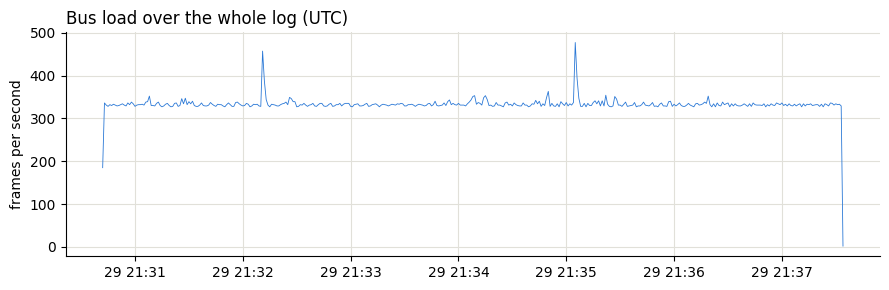

In [37]:
load = pd.read_csv(feats['bus_load_csv'])
load['t'] = pd.to_datetime(load['second'], unit='s', utc=True)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(load['t'], load['frames'], color=BLUE, linewidth=0.6)
ax.set_ylabel('frames per second'); ax.set_title('Bus load over the whole log (UTC)', loc='left'); tidy(ax); plt.tight_layout()

segments = pd.DataFrame(feats['segments'])
segments['start'] = pd.to_datetime(segments['start'], unit='s', utc=True)
segments['end'] = pd.to_datetime(segments['end'], unit='s', utc=True)
segments['duration_h'] = segments['duration_s'] / 3600
segments[['segment', 'start', 'end', 'duration_h']]

## Trip features from the signals
The per-second means give a compact picture of the whole trip. Odometer, total fuel and engine hours are lifetime counters, so their change from first to last message is the distance driven, fuel burned and engine time for this log, from which fuel economy follows.

In [38]:
sig = pd.read_csv(feats['signals_csv'])
sig['hours'] = (sig['second'] - sig['second'].iloc[0]) / 3600

def delta(col):
    s = sig[col].dropna() if col in sig else pd.Series(dtype=float)
    return (s.iloc[0], s.iloc[-1], s.iloc[-1] - s.iloc[0]) if len(s) else (None, None, None)

_, _, dkm = delta('spn245'); _, _, dl = delta('spn250'); _, _, dh = delta('spn247')
moving = sig['spn84'] > 1 if 'spn84' in sig else None
running = sig['spn190'] > 300 if 'spn190' in sig else None
summary = {
    'distance (km)': dkm, 'distance (mi)': dkm * 0.621371 if dkm else None,
    'fuel used (L)': dl, 'fuel used (gal)': dl / 3.78541 if dl else None, 'engine hours': dh,
    'fuel economy (L/100 km)': 100 * dl / dkm if dkm else None,
    'fuel economy (mpg)': (dkm * 0.621371) / (dl / 3.78541) if dl else None,
    'average speed while moving (mph)': sig.loc[moving, 'spn84'].mean() * 0.621371 if moving is not None else None,
    'top speed, 1-s mean (mph)': sig['spn84'].max() * 0.621371 if 'spn84' in sig else None,
    'time with engine running (h)': running.sum() / 3600 if running is not None else None,
    'time idling, engine on and stopped (h)': (running & ~moving).sum() / 3600 if running is not None and moving is not None else None,
}
pd.Series(summary, name='value').to_frame().style.format('{:,.2f}', na_rep='n/a')

,value
distance (km),2.62
distance (mi),1.63
fuel used (L),1.00
fuel used (gal),0.26
engine hours,0.15
fuel economy (L/100 km),38.10
fuel economy (mpg),6.17
average speed while moving (mph),15.13
"top speed, 1-s mean (mph)",33.86
time with engine running (h),0.11


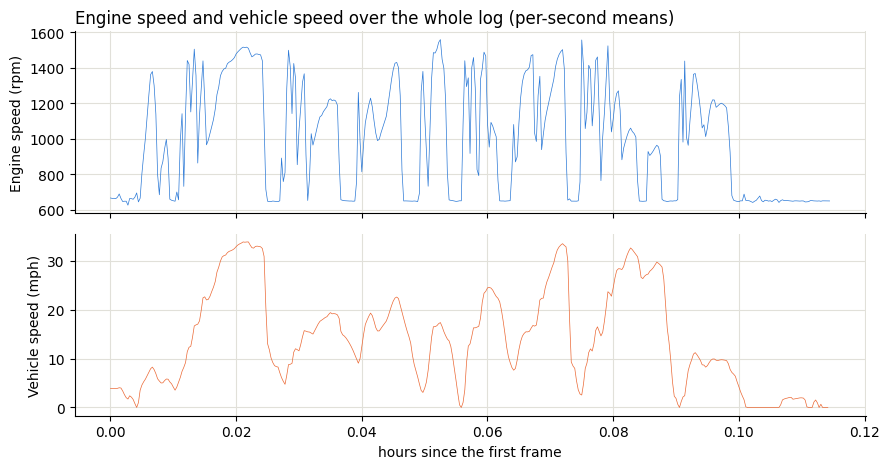

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 4.8))
ax1.plot(sig['hours'], sig['spn190'], color=BLUE, linewidth=0.5); ax1.set_ylabel('Engine speed (rpm)')
ax2.plot(sig['hours'], sig['spn84'] * 0.621371, color=ORANGE, linewidth=0.5); ax2.set_ylabel('Vehicle speed (mph)'); ax2.set_xlabel('hours since the first frame')
ax1.set_title('Engine speed and vehicle speed over the whole log (per-second means)', loc='left'); tidy(ax1); tidy(ax2); plt.tight_layout()

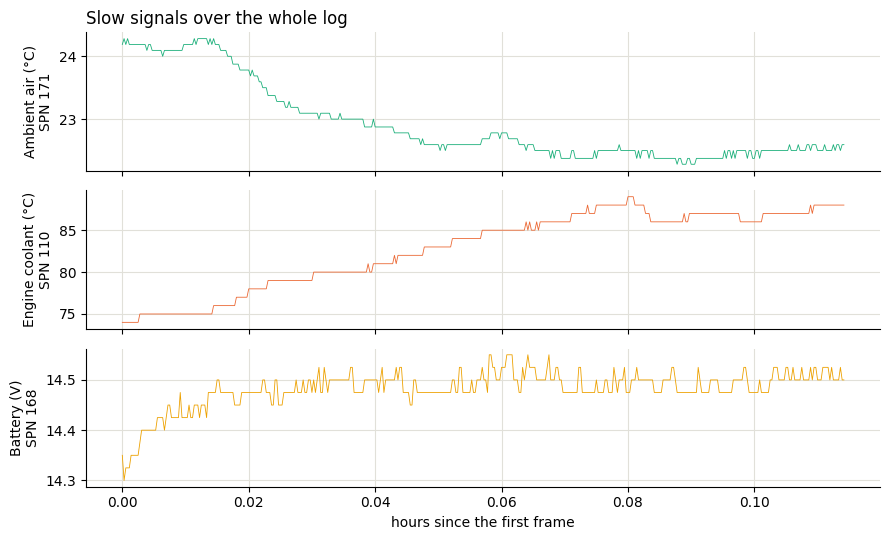

In [40]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 5.5))
for ax, col, label, color in zip(axes, ['spn171', 'spn110', 'spn168'],
                                 ['Ambient air (°C)\nSPN 171', 'Engine coolant (°C)\nSPN 110', 'Battery (V)\nSPN 168'], [AQUA, ORANGE, YELLOW]):
    if col in sig:
        ax.plot(sig['hours'], sig[col], color=color, linewidth=0.6)
    ax.set_ylabel(label); tidy(ax)
axes[-1].set_xlabel('hours since the first frame'); axes[0].set_title('Slow signals over the whole log', loc='left'); plt.tight_layout()

## Where did it go? A map from the GPS messages
Vehicle Position (PGN 65267, 0xFEF3) carries latitude in bytes 1-4 and longitude in bytes 5-8, each a 32-bit value with a resolution of 10⁻⁷ degree and an offset of -210 degrees (the Digital Annex rows for SPNs 584 and 585). Not every truck broadcasts it; it usually comes from a telematics unit or the cab controller. If the log has it, the fixes plot directly as a track. The path length is the sum of great-circle distances between consecutive fixes (jumps over 5 km, gaps between segments or bad fixes, are skipped) and can be checked against the odometer.

The interactive map uses `folium` (`pip install folium`) and needs an internet connection for map tiles; the static plot needs neither.

In [41]:
if feats['gps']:
    gps = pd.read_csv(feats['gps_csv'])
    print(f"{len(gps):,} fixes; path length {feats['gps']['path_km']:,} km" + (f" vs. odometer change {dkm:,.1f} km" if dkm else ''))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(gps['lon'], gps['lat'], color=BLUE, linewidth=1.2)
    ax.scatter(gps['lon'].iloc[0], gps['lat'].iloc[0], color=AQUA, s=60, zorder=3, label='start')
    ax.scatter(gps['lon'].iloc[-1], gps['lat'].iloc[-1], color=ORANGE, s=60, zorder=3, label='end')
    ax.set_aspect(1 / math.cos(math.radians(gps['lat'].mean())))       # keep east-west and north-south distances honest
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude'); ax.set_title('GPS track from PGN 65267', loc='left')
    ax.margins(0.08); tidy(ax); ax.legend(frameon=False, loc='best'); plt.tight_layout()
else:
    print('No Vehicle Position (PGN 65267) messages in this log, so there is no track to draw.')

No Vehicle Position (PGN 65267) messages in this log, so there is no track to draw.


In [42]:
if feats['gps']:
    try:
        import folium
        step = max(1, len(gps) // 5000)                                      # keep the HTML small
        pts = gps.iloc[::step][['lat', 'lon']].values.tolist()
        m = folium.Map(location=[gps['lat'].mean(), gps['lon'].mean()], zoom_start=5, tiles='OpenStreetMap')
        folium.PolyLine(pts, color=BLUE, weight=3, opacity=0.9).add_to(m)
        folium.Marker(pts[0], tooltip='start', icon=folium.Icon(color='green')).add_to(m)
        folium.Marker(pts[-1], tooltip='end', icon=folium.Icon(color='orange')).add_to(m)
        m.fit_bounds([[gps['lat'].min(), gps['lon'].min()], [gps['lat'].max(), gps['lon'].max()]])
        map_file = os.path.splitext(BIG_FILE)[0] + '_map.html'
        m.save(map_file); print('interactive map saved to', map_file)
        display(m)
    except ImportError:
        print('folium is not installed (pip install folium); the static track above is the map.')

    # where and when did each segment start and end?
    def fix_near(t):
        i = (gps['timestamp'] - t).abs().idxmin()
        return f"{gps.loc[i, 'lat']:.4f}, {gps.loc[i, 'lon']:.4f}" if abs(gps.loc[i, 'timestamp'] - t) < 300 else 'no fix'
    seg_pos = segments[['segment', 'start', 'end', 'duration_h']].copy()
    seg_pos['start position'] = [fix_near(t) for t in pd.DataFrame(feats['segments'])['start']]
    seg_pos['end position'] = [fix_near(t) for t in pd.DataFrame(feats['segments'])['end']]
    display(seg_pos)

## Checking the logger's clock against the vehicle's
The timestamps in a candump file come from the logging computer's clock. A Raspberry Pi without a real-time clock or a network connection starts at whatever time it last knew, so the timestamps can be off by hours or years even though the intervals between frames are right. The vehicle broadcasts its own Time/Date (PGN 65254, 0xFEE6); comparing the two is a cheap integrity check on the evidence.

In [43]:
c = feats['clock']
if c and c.get('valid'):
    print(f"{c['valid']:,} valid Time/Date messages of {c['messages']:,}; vehicle clock {c['vehicle_time_first']} -> {c['vehicle_time_last']} UTC")
    print(f"logger timestamps {feats['start_utc']} -> {feats['end_utc']} UTC")
    off = c['median_offset_s']
    print(f"median (vehicle - logger) = {off:+.0f} s = {off/3600:+.2f} h" + ('  (consistent with a time-zone or DST difference)' if abs(off) >= 3000 and min(abs(off) % 3600, 3600 - abs(off) % 3600) < 120 else ''))
elif c:
    print(f"{c['messages']:,} Time/Date messages, none with a valid date. Example decode: {c['sample']}")
    print('A month of 0 and a year of 2007 mean the ECU that sends Time/Date has never had its clock set;')
    print('the logger timestamps are the only usable time reference in this log.')
else:
    print('No Time/Date (PGN 65254) messages in this log.')

412 Time/Date messages, none with a valid date. Example decode: {'seconds': 34.0, 'minutes': 5.0, 'hours': 1.0, 'month': 0.0, 'day': 8.0, 'year': 2007.0}
A month of 0 and a year of 2007 mean the ECU that sends Time/Date has never had its clock set;
the logger timestamps are the only usable time reference in this log.


## Summary of the large-file analysis
Streaming the file once turned two gigabytes of text into a page of facts: the vehicle (from its VIN), the ECUs on the network and how much each talks, when the logger ran, how far the truck went and how much fuel it burned, what the weather was like, and where it was. None of that needed more than a few hundred megabytes of memory, and all of it is cached so the plots above re-run instantly.

### Exercise
1. The frames-per-second plot has a characteristic level while the engine is running. What is the utilisation of a 250 kbit/s bus at that level, using 130 bits per frame?
2. From the per-second vehicle speed, how many minutes were spent above 70 mph? Use the GPS track to guess which states those were in.
3. Fault codes: DM1 (PGN 65226) is broadcast when a lamp is on. Extend the single pass to count DM1 frames per hour and find the first time a fault appeared. (The DTC layout is in J1939-73: SPN in the low 19 bits, FMI in the next 5, occurrence count in the last byte.)
4. Borrow an idea from canarchy: compute the median and MAD of the inter-frame gap for each CAN ID over the first segment, then flag seconds in the rest of the log where an ID's timing departs by more than five scaled MADs. What do the flagged seconds have in common?

# Summary
* Open-source tools already cover much of the J1939 workflow: pretty_j1939 for decoding, canarchy for reverse engineering and anomaly detection, TruckDevil for active assessment, the TruckHacking hardware for the other truck networks, CAN Logger 3 for logs that can be trusted as evidence, and the Linux `can-j1939` stack for building applications. Knowing what each is good for saves reinventing it; building small versions by hand, as we did here, is how you learn to read them.
* A logger in C or Rust costs 10-20 times less CPU per frame than one in Python, which matters on small computers and busy or multi-channel networks, and hardly at all for one 250 kbit/s bus on a laptop. The number that decides whether a logger is good enough is the receive-queue overrun count, not the language.
* Parsing a log **once** into SQLite, with the J1939 keys as indexed columns, turns every later question into a query. The index order should follow the questions you ask most; for one vehicle, lead with the source address.
* The Digital Annex becomes a database in a few dozen lines once its columns are understood, and then a general decoder is four numbers per SPN plus the indicator rules for "not available" and "error".
* Files too big to fit in memory are streamed once, with everything you might want collected in a single pass and cached; the head and tail of the file tell you what to expect before you start.